In [1]:
%load_ext autoreload
%autoreload 2 
    

In [43]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))


# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

# NeuroDSP and FOOOF modules
from neurodsp import spectral
from fooof import FOOOF


# Custom modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, FILTER_SETTINGS

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook 



## Cell 42  (Whole patch, IC)
### Analyze whole patch clamp

In [51]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

#### Step 0: Get loaded data

In [52]:
patch_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [53]:
#get cell number 
cell_num = patch_dir.split('/')[len(patch_dir.split('/'))-1].split('_')[0]


#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

### Compute patch clamp spike features for cell 42

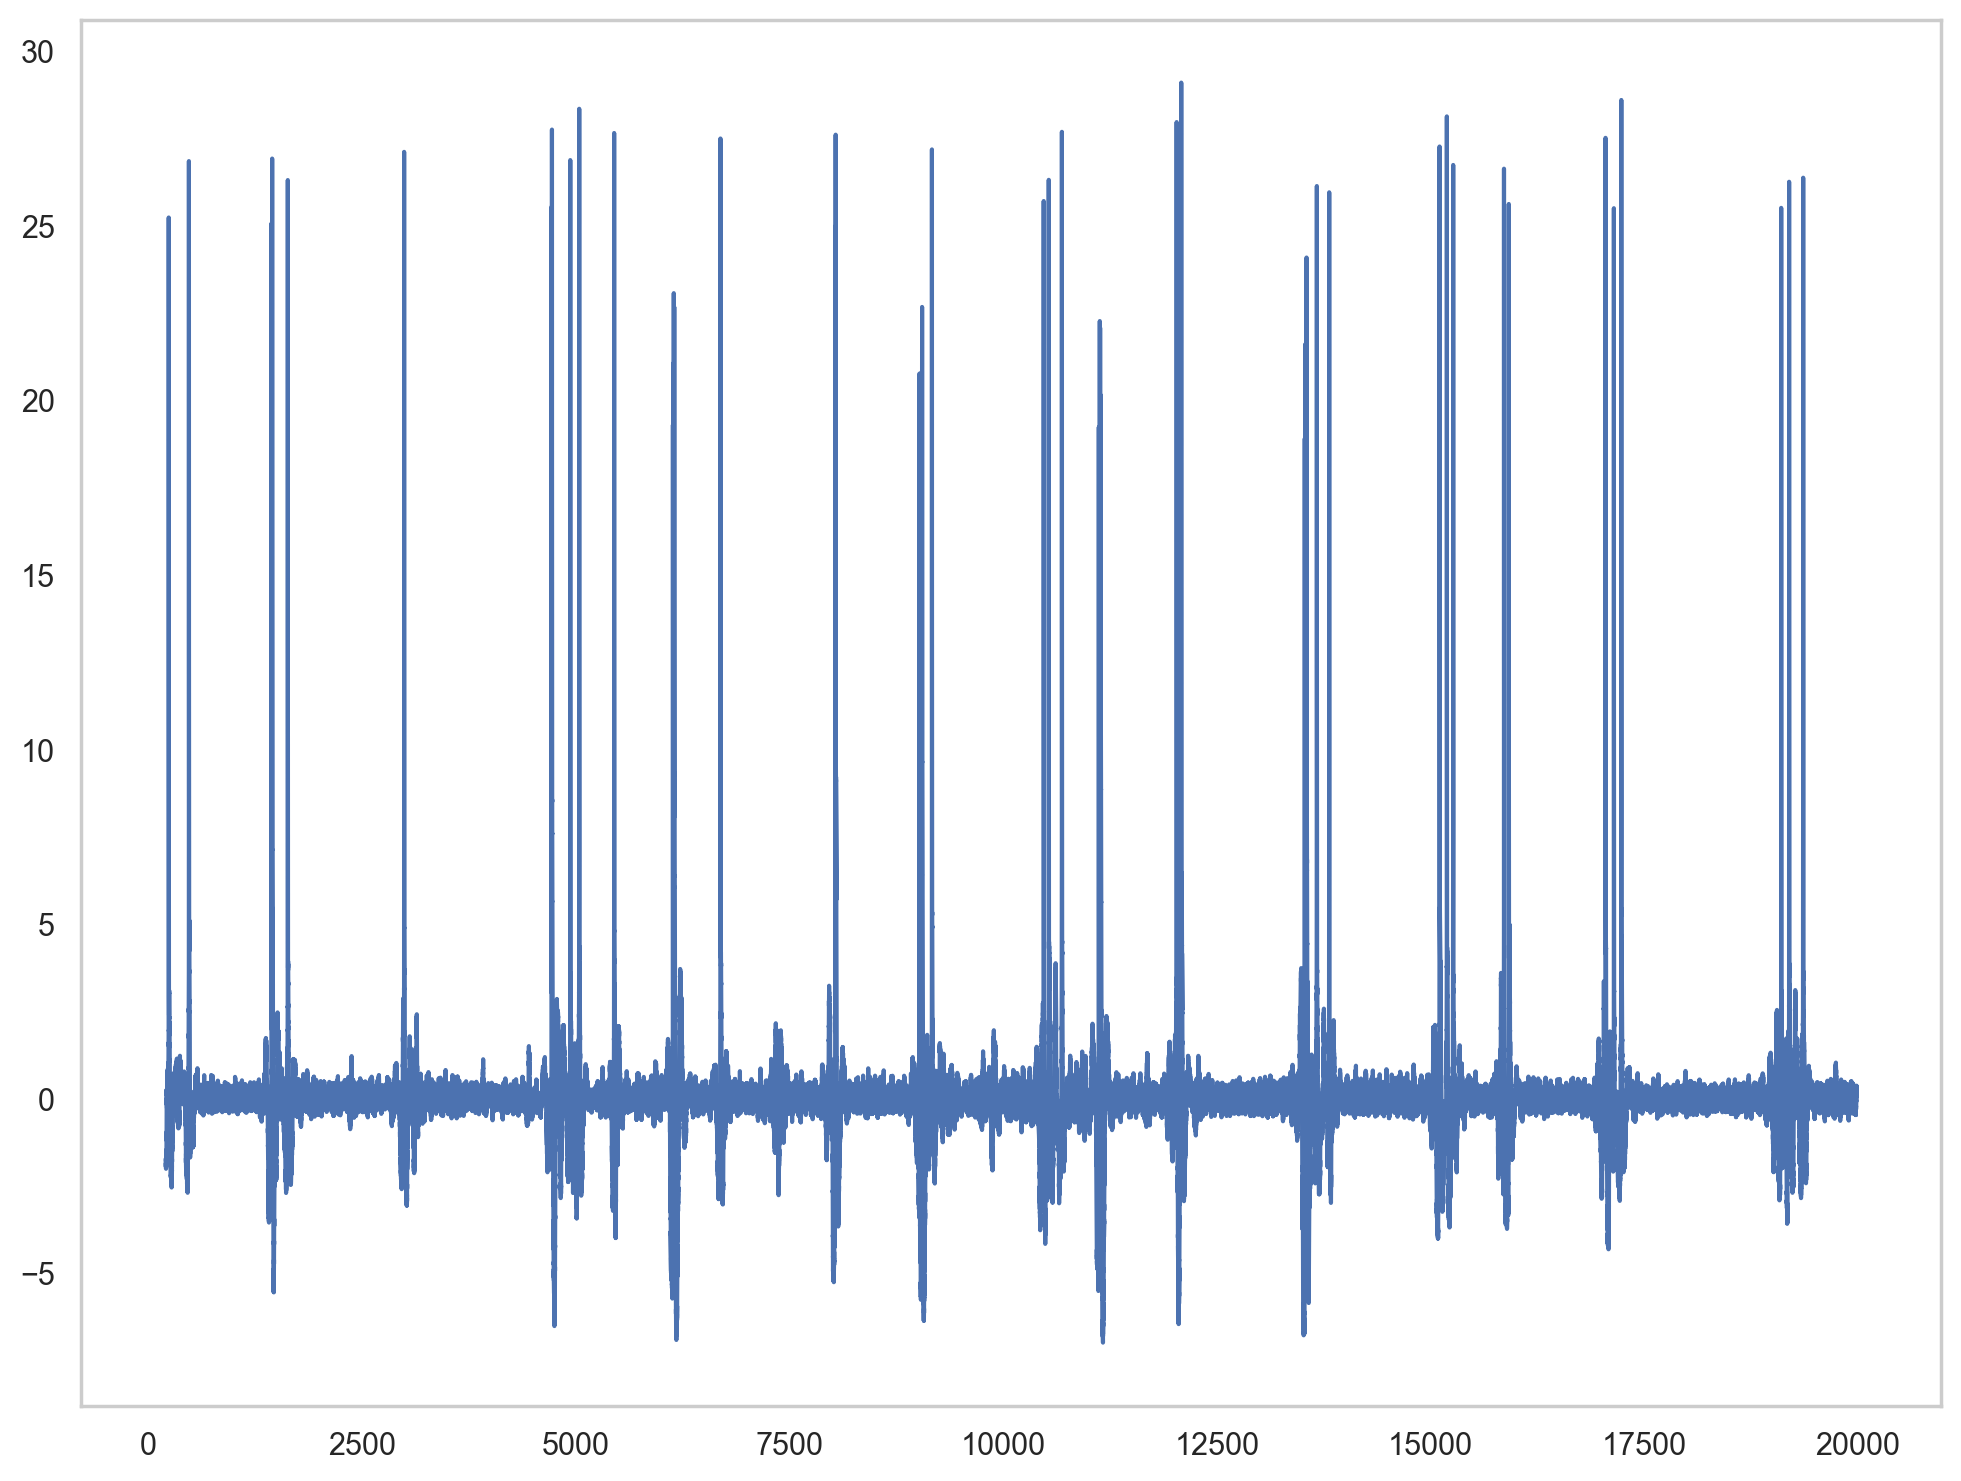

In [56]:
plt.plot(patch_times[10000:1000000], patch_filt[10000:1000000])

In [57]:

#threshold in mVs
sp = Spike(thresh_amp=10, window_length=(5., 5.), smooth_frac=.01)


sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/626 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### Filter spikes 

In [58]:
sp.filter_features()  # Applies default filters in-place

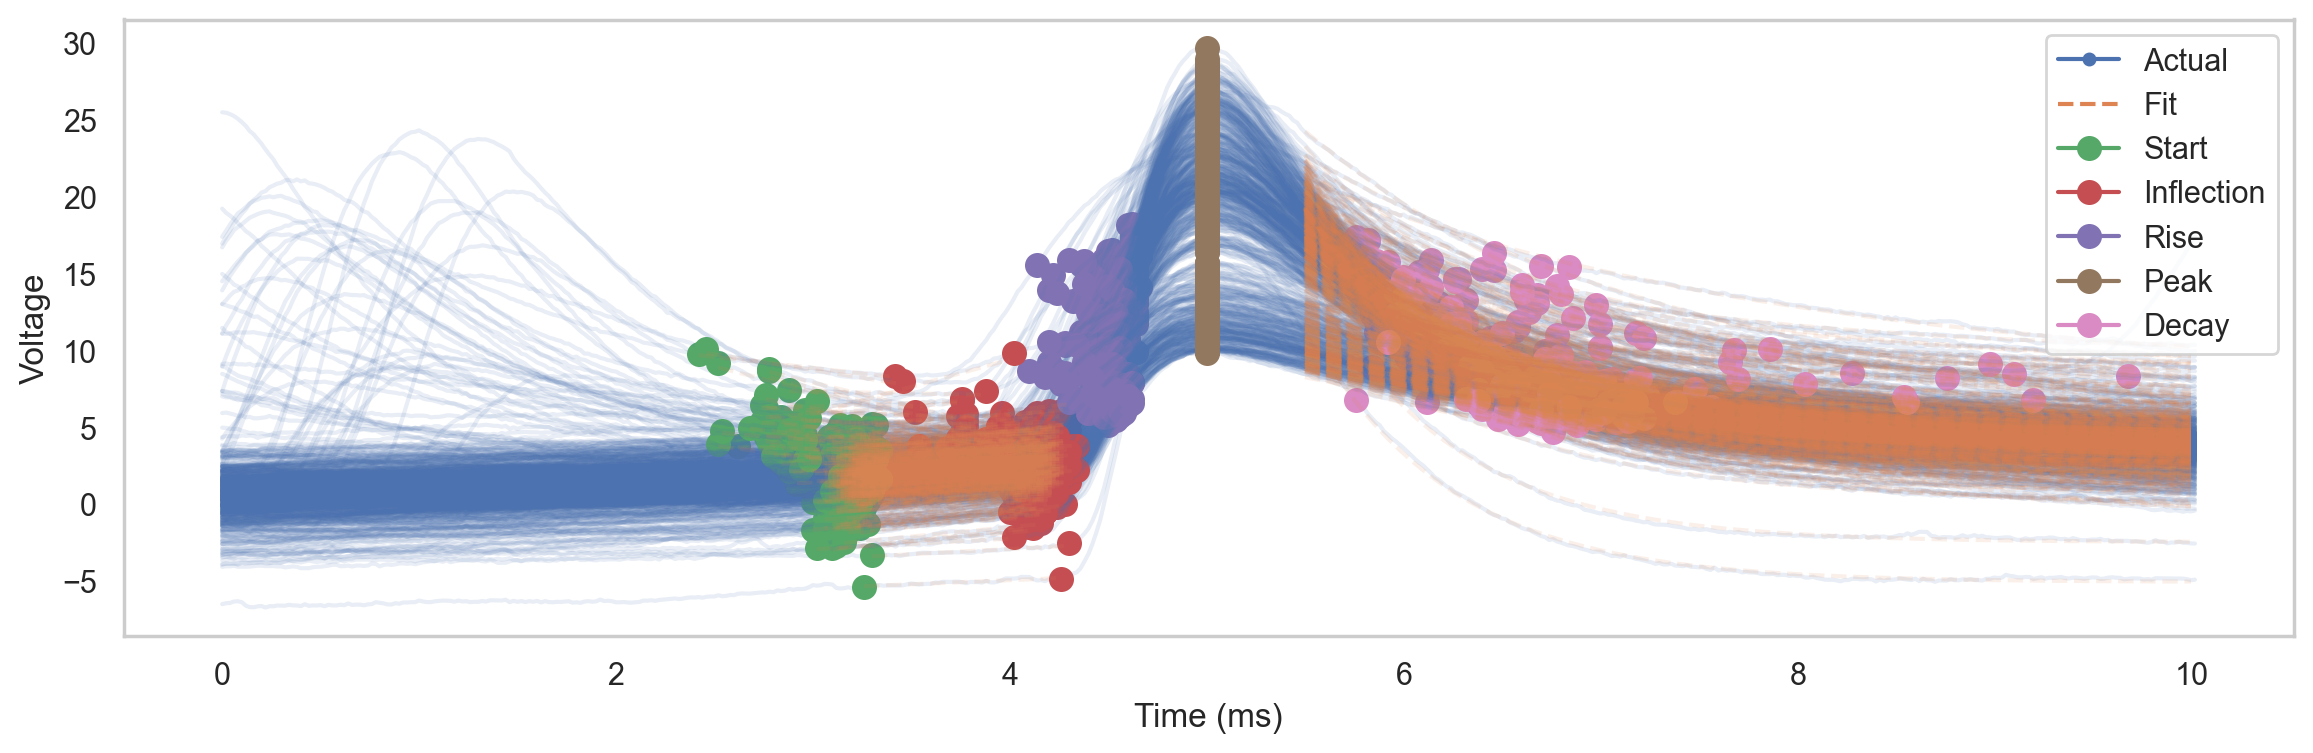

In [62]:
sp.plot(show_points=True)

### Get spike dataframe (with spike times column)

In [68]:
df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

#### Plot correlations 

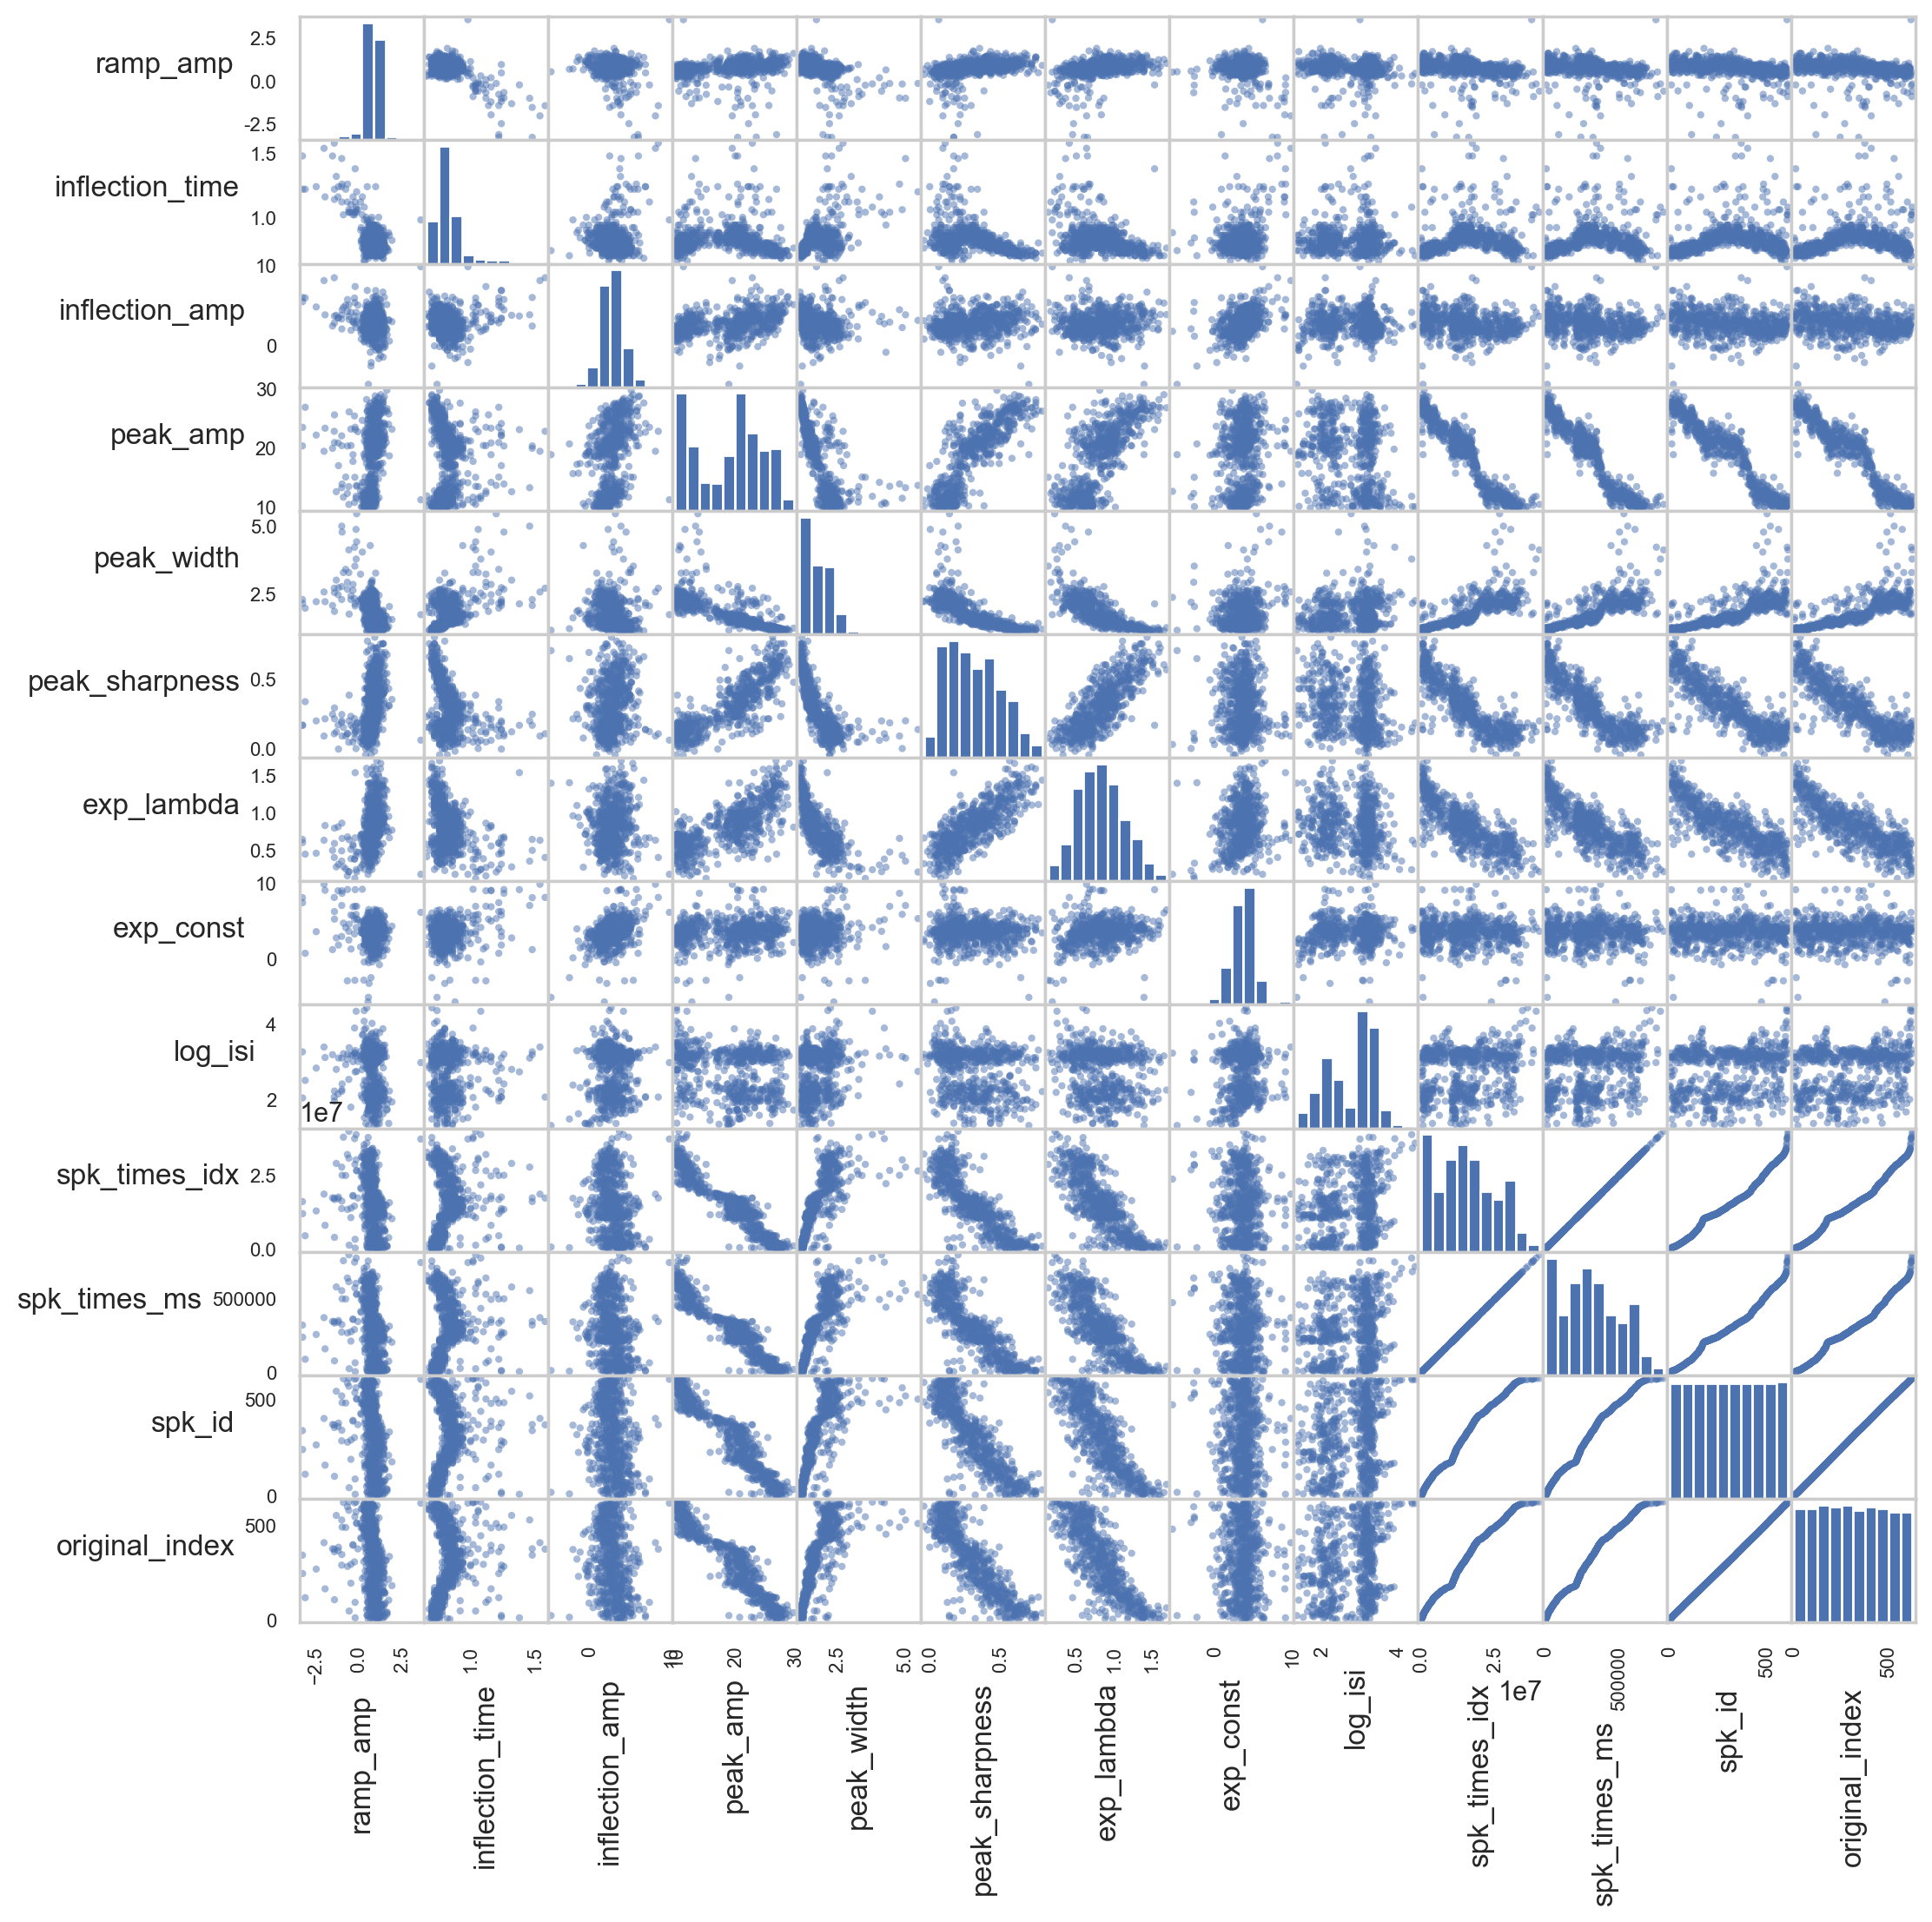

In [69]:


axes = pd.plotting.scatter_matrix(df_features, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()

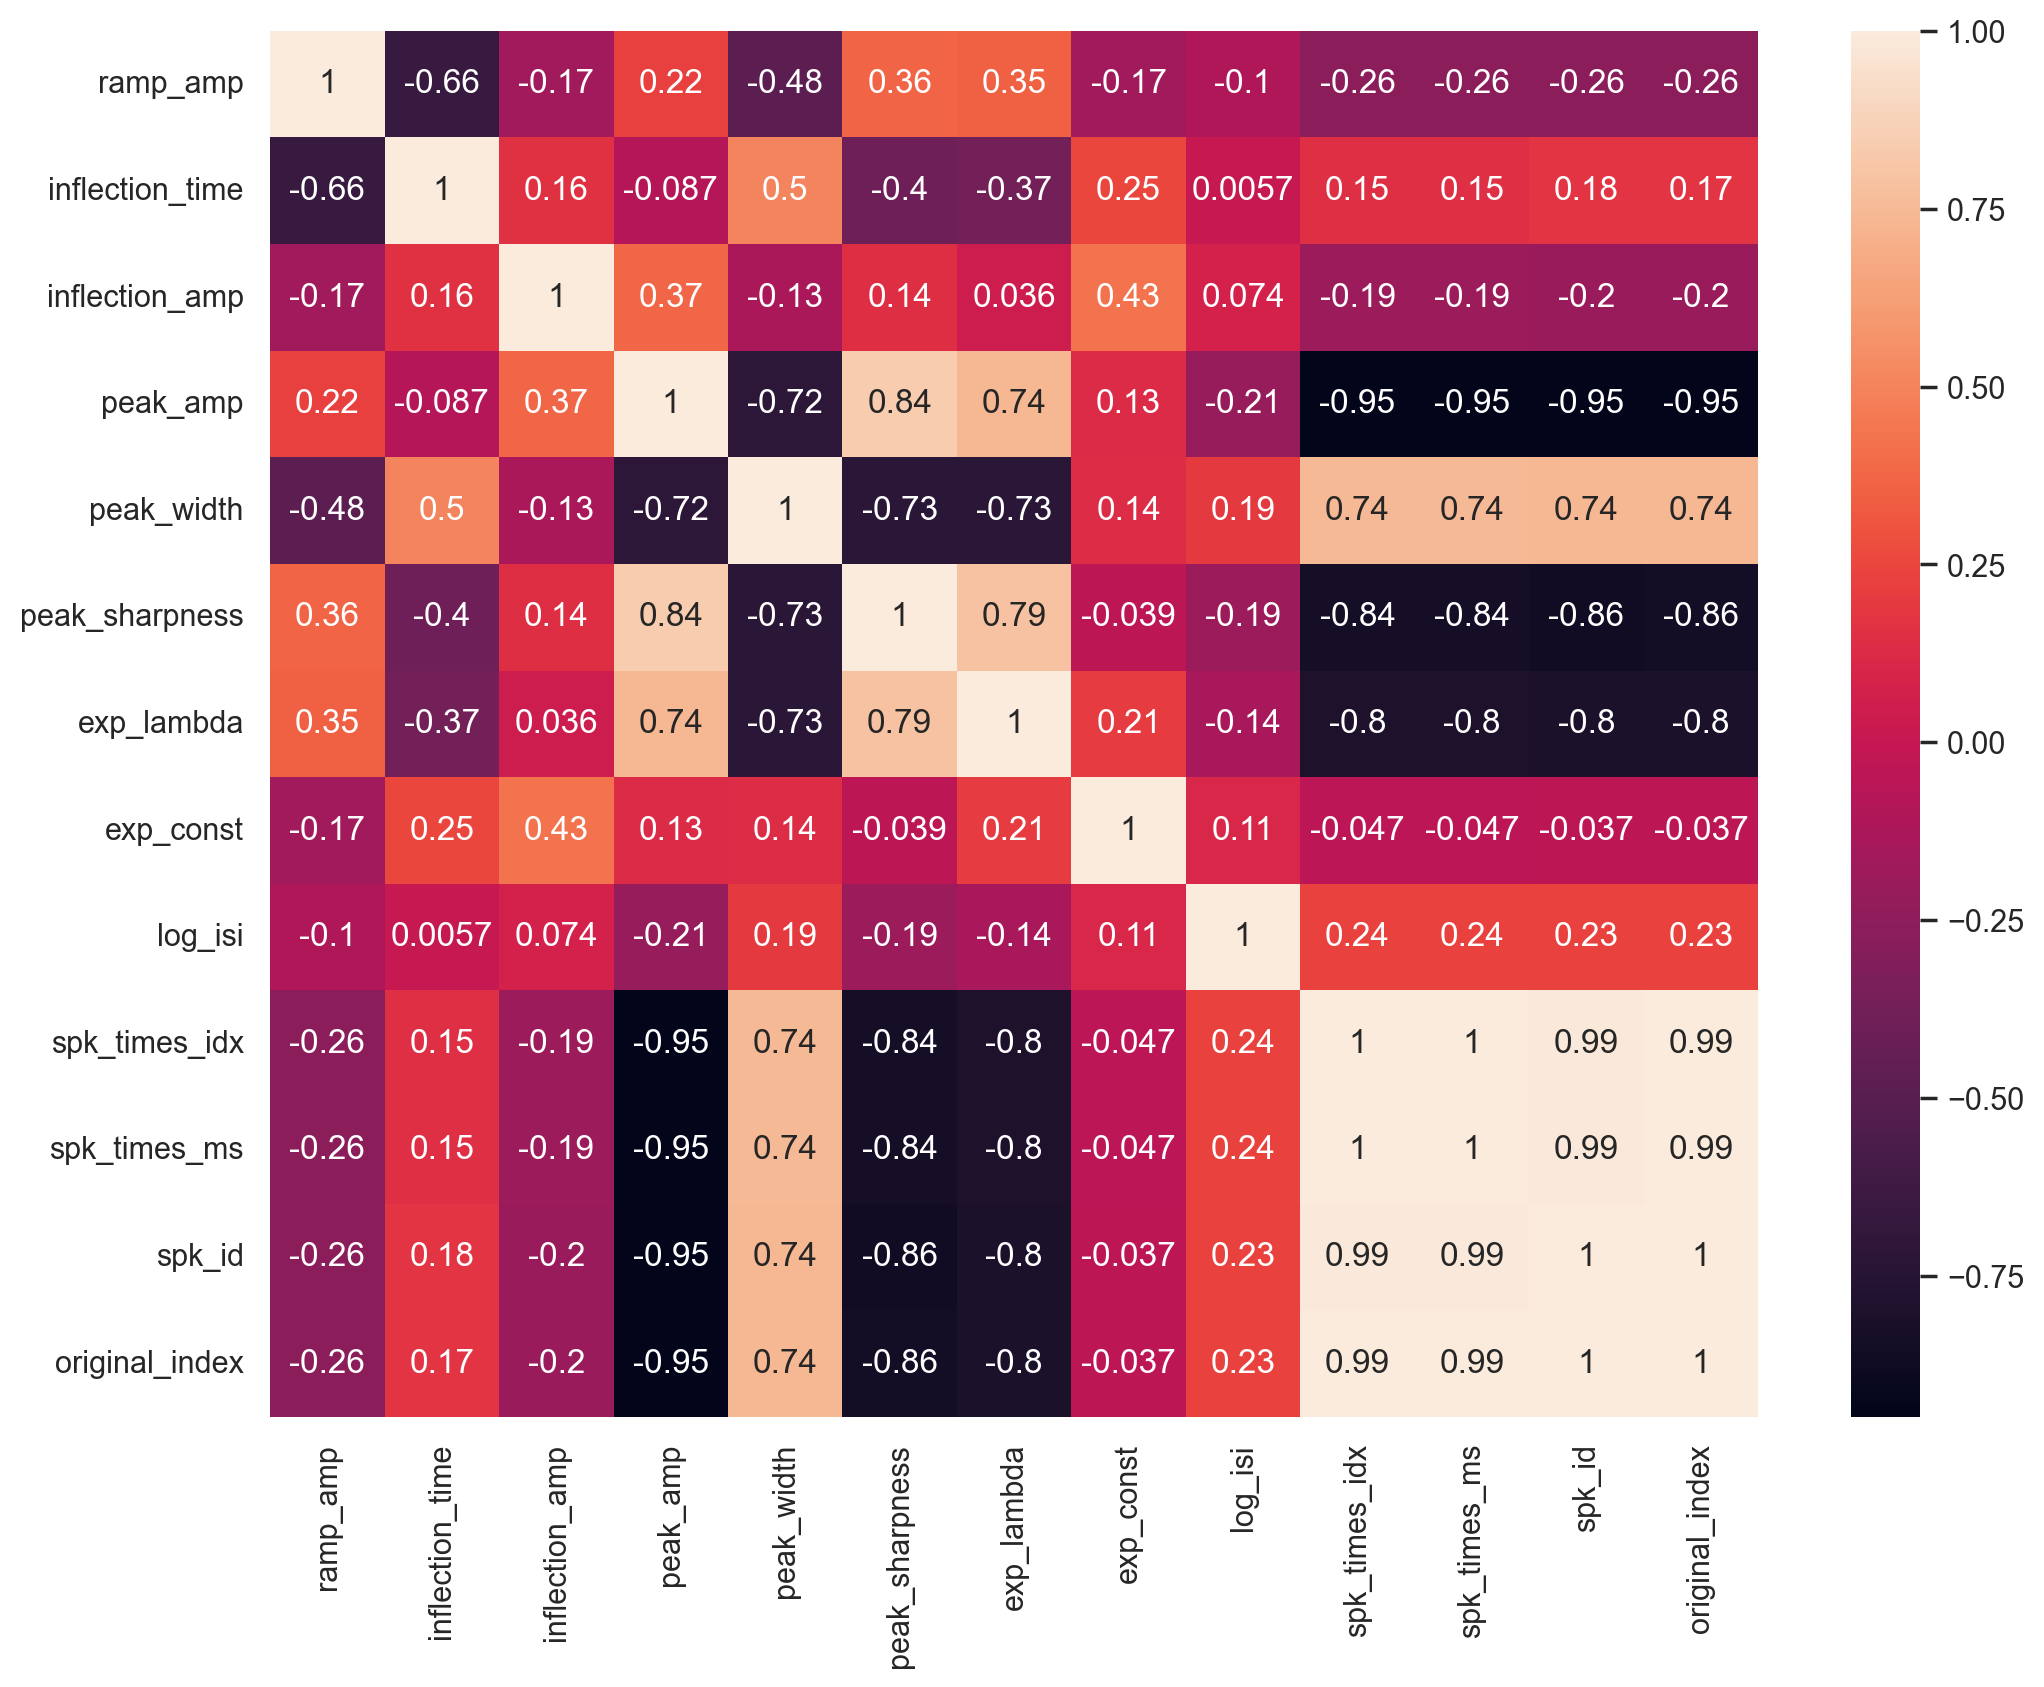

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,original_index
ramp_amp,1.0***,-0.66***,-0.17***,0.22***,-0.48***,0.36***,0.35***,-0.17***,-0.1*,-0.26***,-0.26***,-0.26***,-0.26***
inflection_time,-0.66***,1.0***,0.16***,-0.09*,0.5***,-0.4***,-0.37***,0.25***,0.01,0.15***,0.15***,0.18***,0.17***
inflection_amp,-0.17***,0.16***,1.0***,0.37***,-0.13**,0.14***,0.04,0.43***,0.07,-0.19***,-0.19***,-0.2***,-0.2***
peak_amp,0.22***,-0.09*,0.37***,1.0***,-0.72***,0.84***,0.74***,0.13**,-0.21***,-0.95***,-0.95***,-0.95***,-0.95***
peak_width,-0.48***,0.5***,-0.13**,-0.72***,1.0***,-0.73***,-0.73***,0.14***,0.19***,0.74***,0.74***,0.74***,0.74***
peak_sharpness,0.36***,-0.4***,0.14***,0.84***,-0.73***,1.0***,0.79***,-0.04,-0.19***,-0.84***,-0.84***,-0.86***,-0.86***
exp_lambda,0.35***,-0.37***,0.04,0.74***,-0.73***,0.79***,1.0***,0.21***,-0.14***,-0.8***,-0.8***,-0.8***,-0.8***
exp_const,-0.17***,0.25***,0.43***,0.13**,0.14***,-0.04,0.21***,1.0***,0.11**,-0.05,-0.05,-0.04,-0.04
log_isi,-0.1*,0.01,0.07,-0.21***,0.19***,-0.19***,-0.14***,0.11**,1.0***,0.24***,0.24***,0.23***,0.23***
spk_times_idx,-0.26***,0.15***,-0.19***,-0.95***,0.74***,-0.84***,-0.8***,-0.05,0.24***,1.0***,1.0***,0.99***,0.99***


In [70]:
#df_features_correlation = df_features.corr()
# Plot the heatmap and annotation on it
sns.heatmap(df_features.corr(), xticklabels=df_features.corr().columns,
            yticklabels=df_features.corr().columns, annot=True)
plt.show()
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

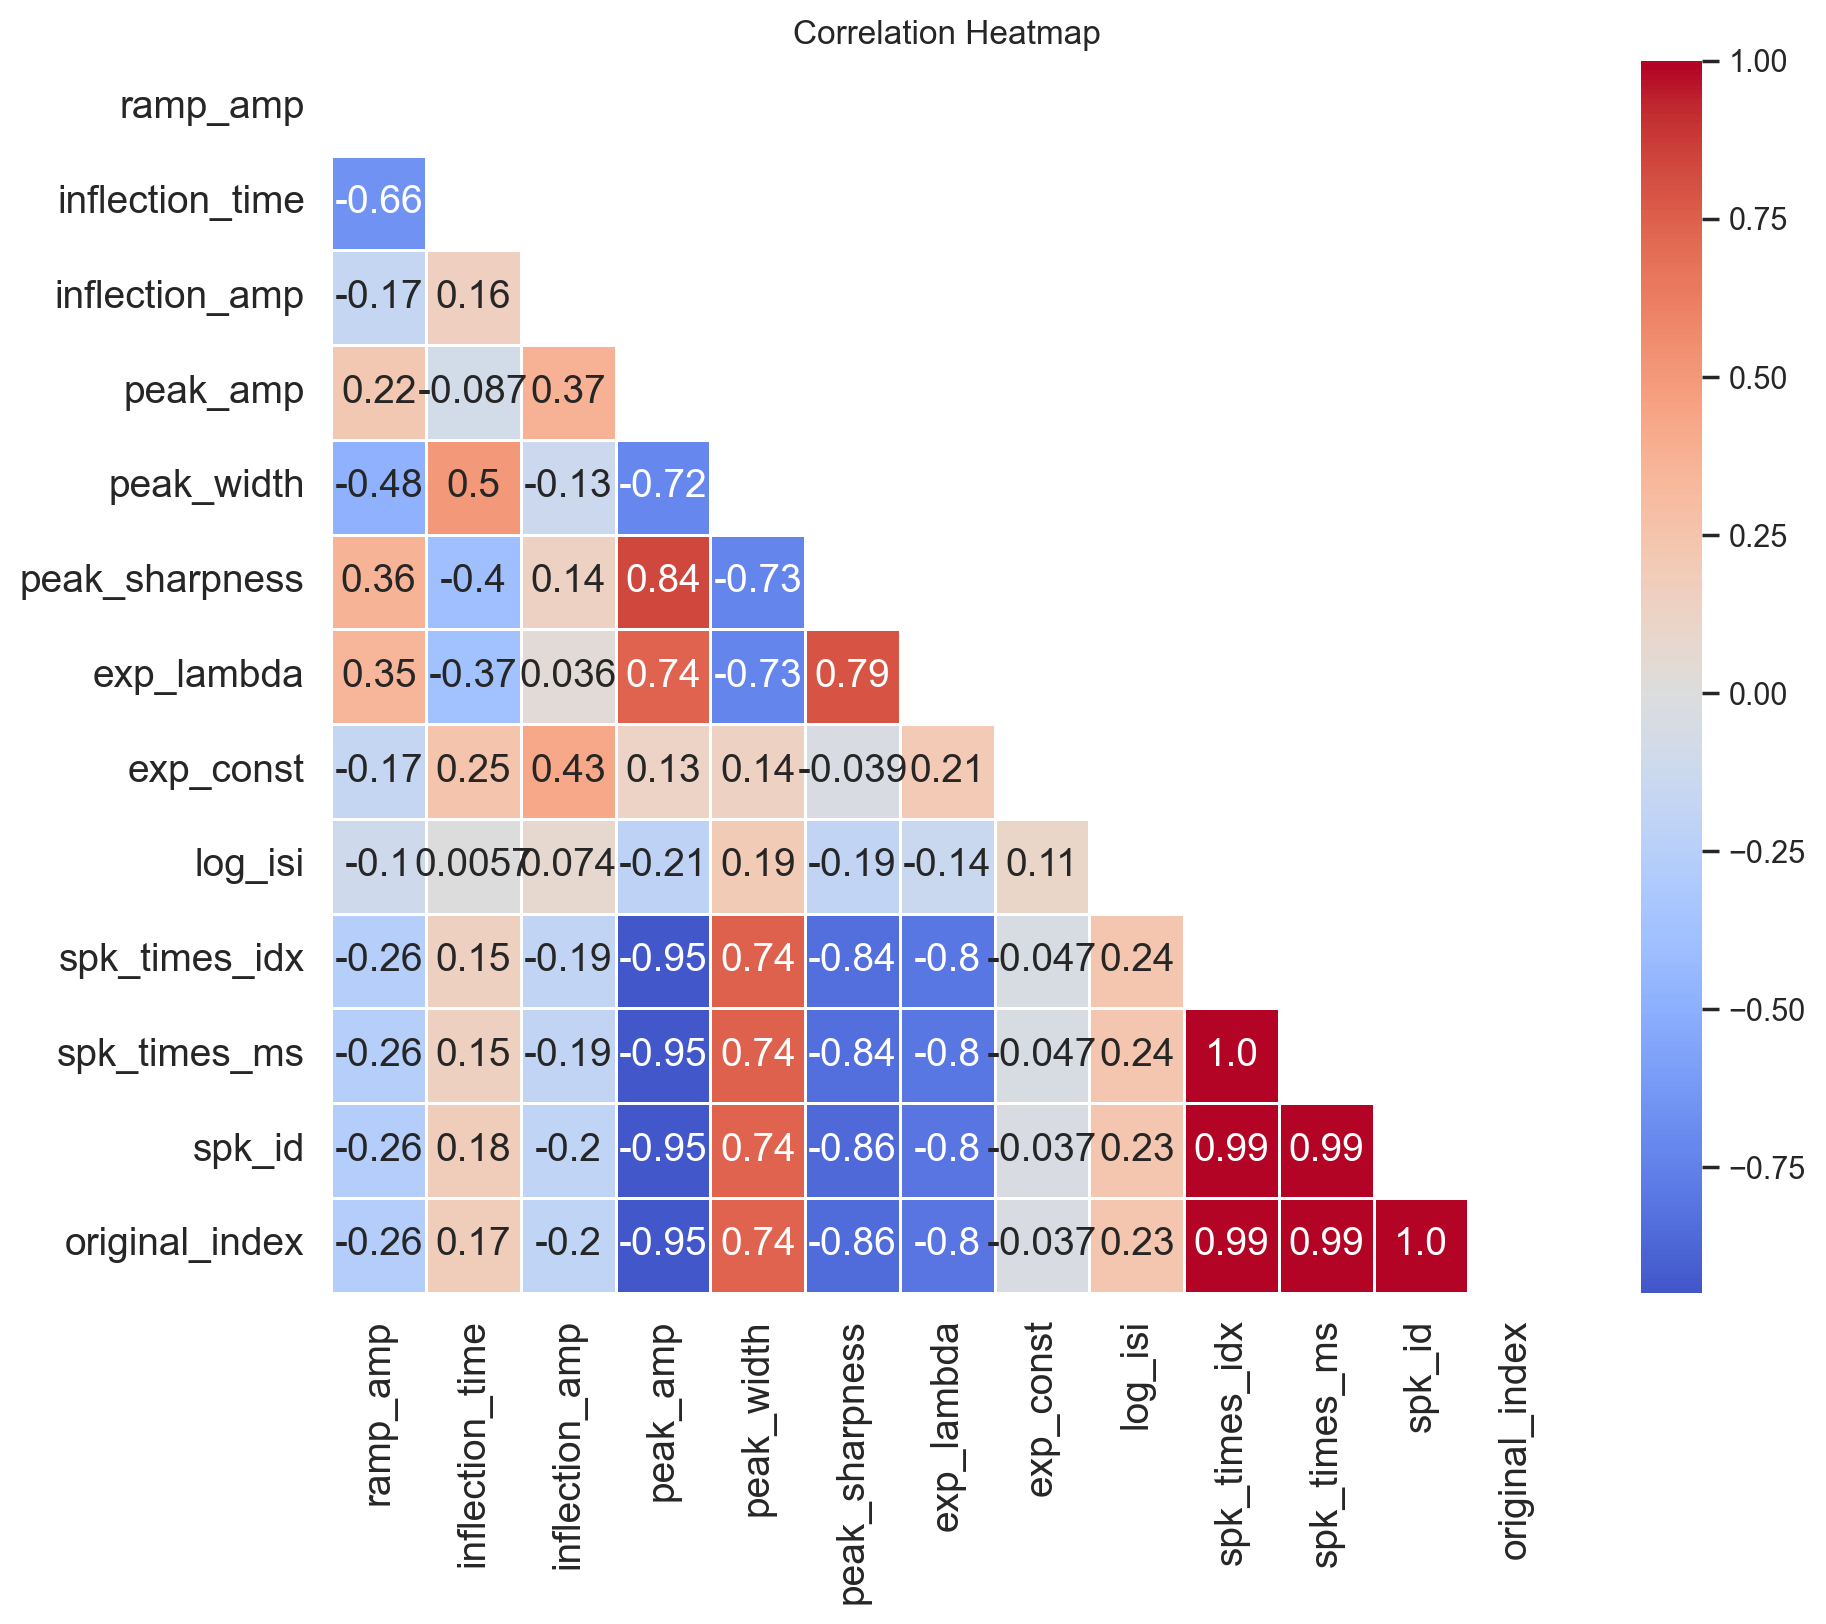

In [71]:
# Calculate correlation matrix and p-values
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval < 0.05  # Create a mask for significant p-values

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(rho, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(rho, mask=mask, cmap='coolwarm', annot=True, fmt='.2', linewidths=0.5, center=0, square=True,  annot_kws={"size": 14})
# Increase fontsize of tick labels on both axes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title('Correlation Heatmap')
plt.show()


## Linear regression model to predict time of next spike (isi) based on inflection features 

(array([ 23.,  50.,  99.,  68.,  30., 164., 141.,  26.,   6.,   3.]),
 array([1.31952296, 1.63083703, 1.9421511 , 2.25346518, 2.56477925,
        2.87609332, 3.18740739, 3.49872146, 3.81003553, 4.1213496 ,
        4.43266367]),
 <BarContainer object of 10 artists>)

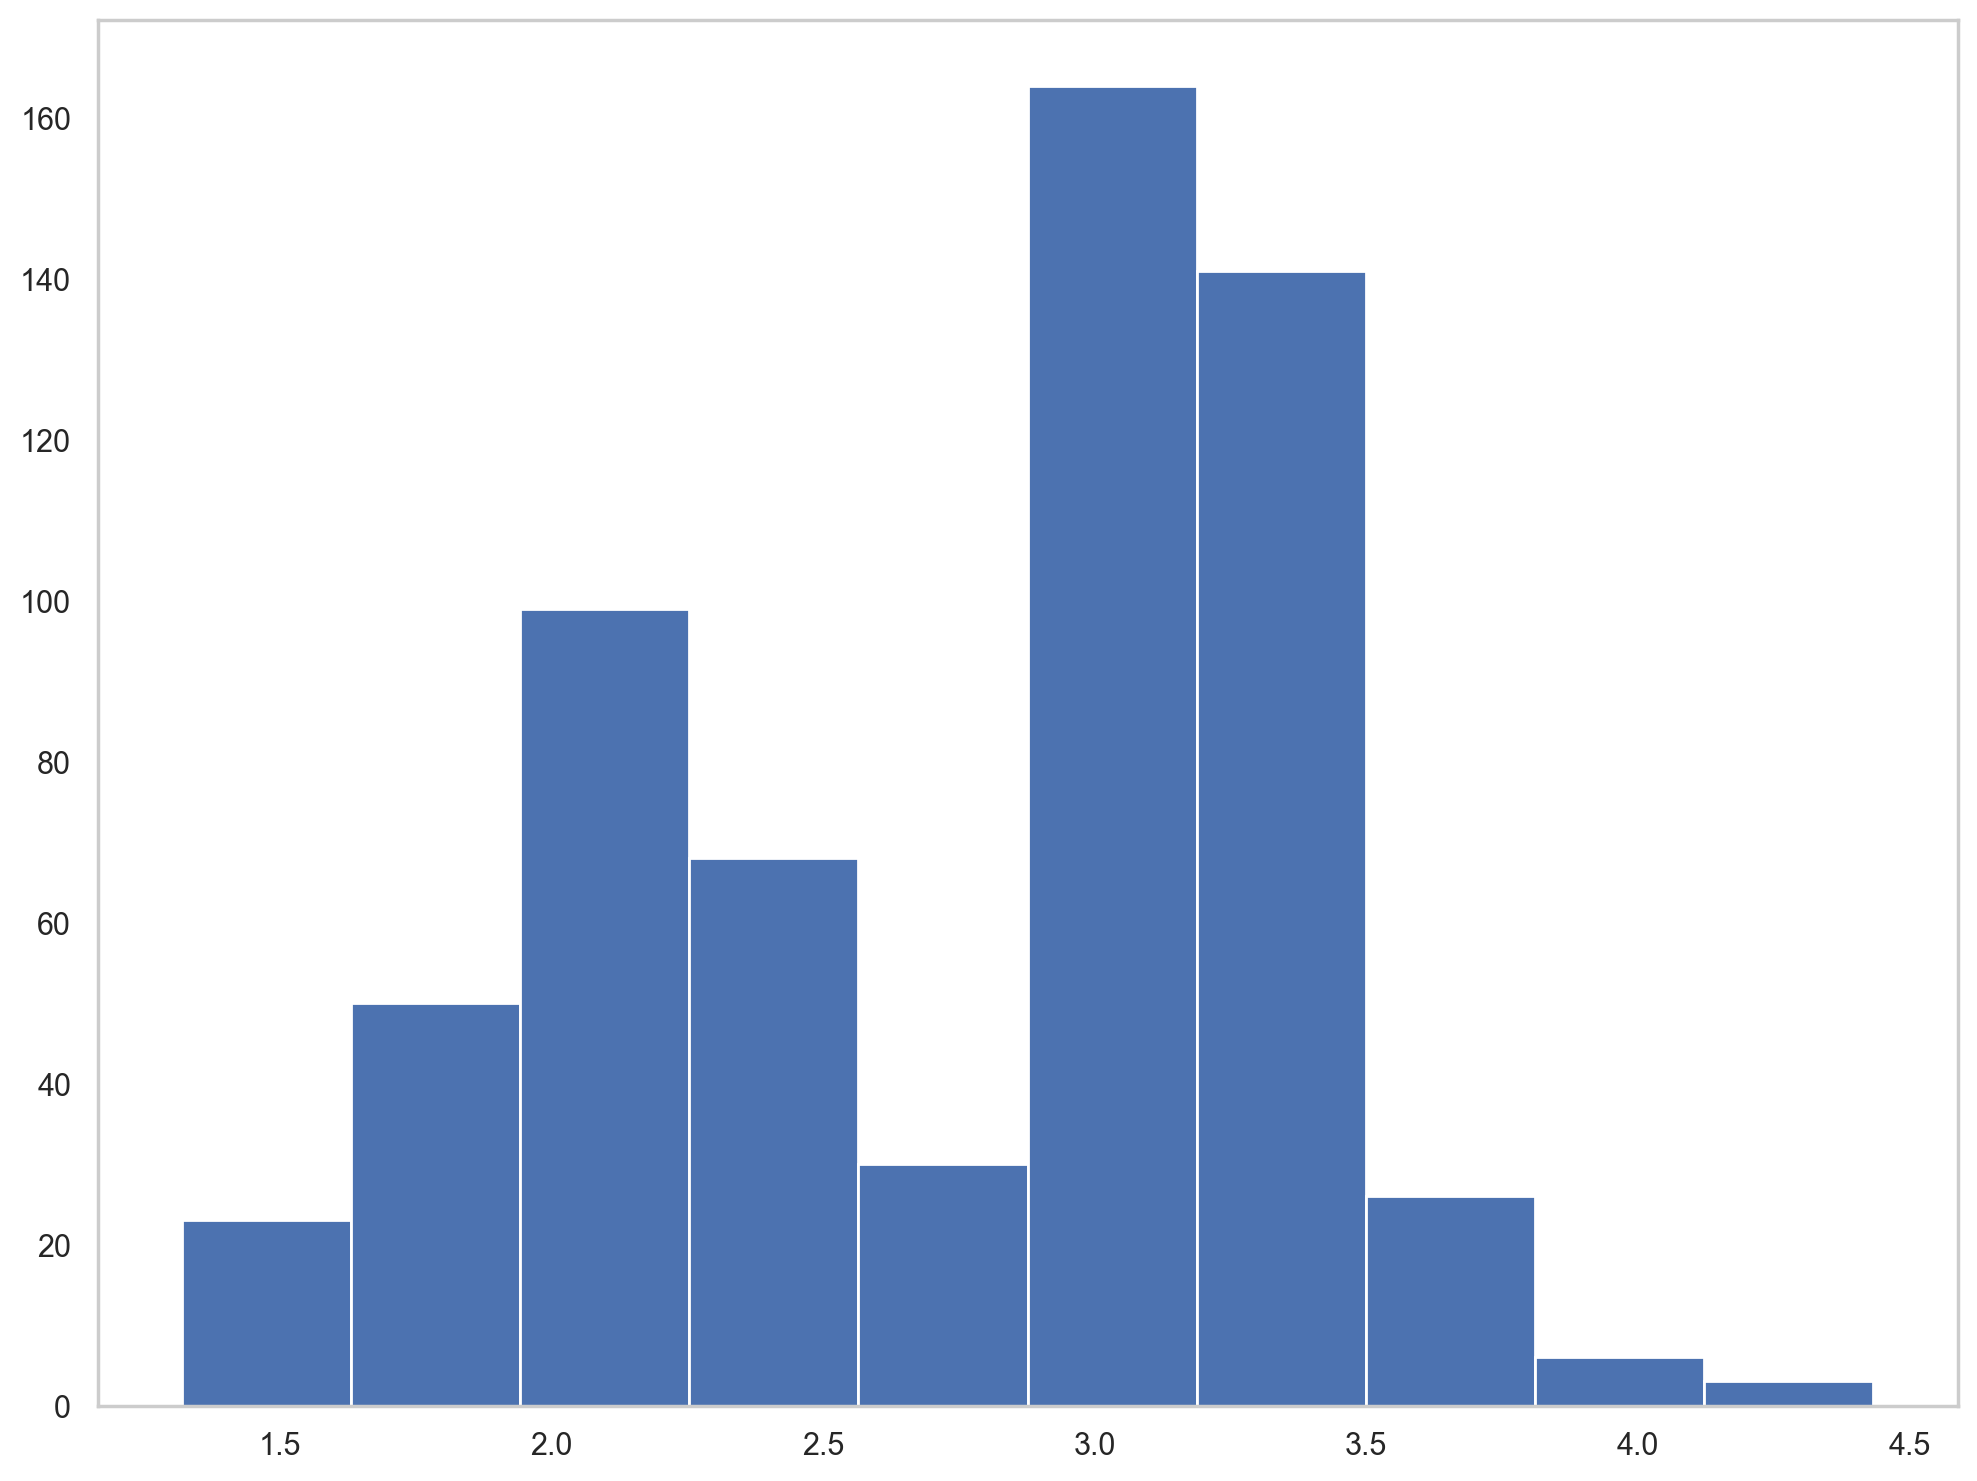

In [19]:
plt.hist(df_features['log_isi'])

In [20]:
#split two clusters and then generate two different models?
isis = df_features['log_isi'].values
isis_reshaped = isis.reshape(-1, 1) 



Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


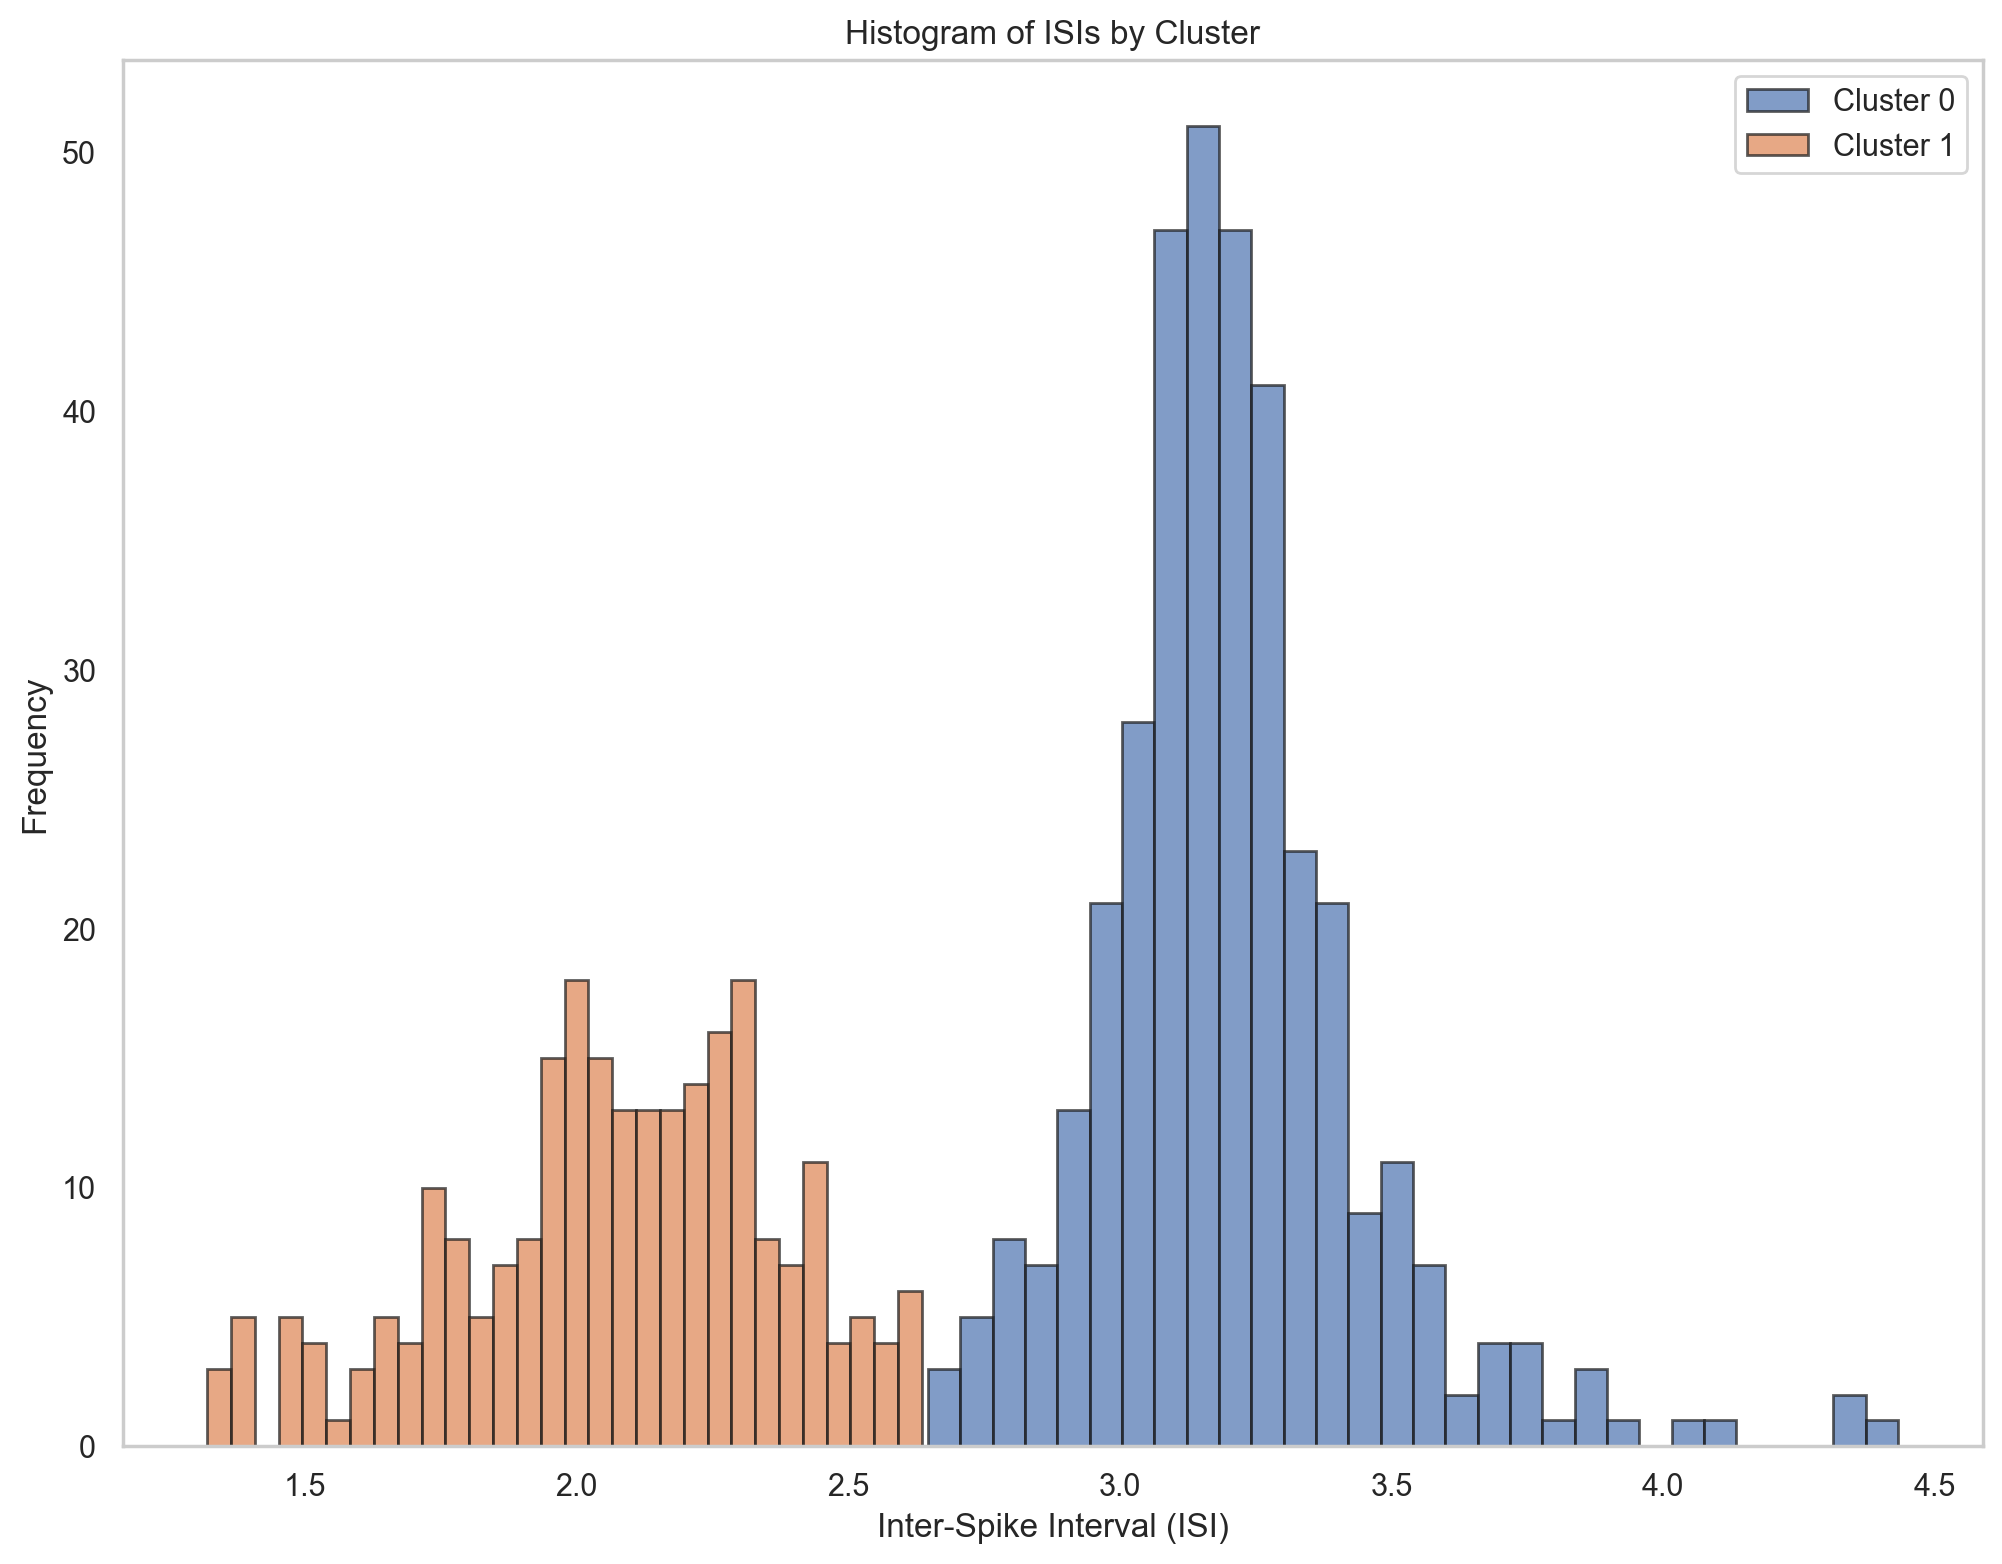

In [21]:


# Perform MiniBatchKMeans clustering
mini_kmeans = MiniBatchKMeans(n_clusters=2, random_state=0, batch_size=100).fit(isis_reshaped)
clusters = mini_kmeans.labels_

# Visualize the clusters
plt.hist(isis[clusters == 0], bins=30, edgecolor='k', alpha=0.7, label='Cluster 0')
plt.hist(isis[clusters == 1], bins=30, edgecolor='k', alpha=0.7, label='Cluster 1')
plt.xlabel('Inter-Spike Interval (ISI)')
plt.ylabel('Frequency')
plt.title('Histogram of ISIs by Cluster')
plt.legend()
plt.show()

In [22]:
#separate features and target

features = df_features.drop(columns=['log_isi']).values
target = df_features['log_isi'].values

# Split features and target based on clusters
features_cluster_0 = features[clusters == 0]
target_cluster_0 = target[clusters == 0]
features_cluster_1 = features[clusters == 1]
target_cluster_1 = target[clusters == 1]

original_indices = df_features['original_index'].values
original_indices_cluster_0 = original_indices[clusters == 0]
original_indices_cluster_1 = original_indices[clusters == 1]

In [23]:
df_features['inflection_time']

0      0.76
1      0.70
2      0.84
3      0.72
4      0.72
       ... 
618    0.98
620    1.02
621    0.70
622    1.02
624    1.08
Name: inflection_time, Length: 610, dtype: float64

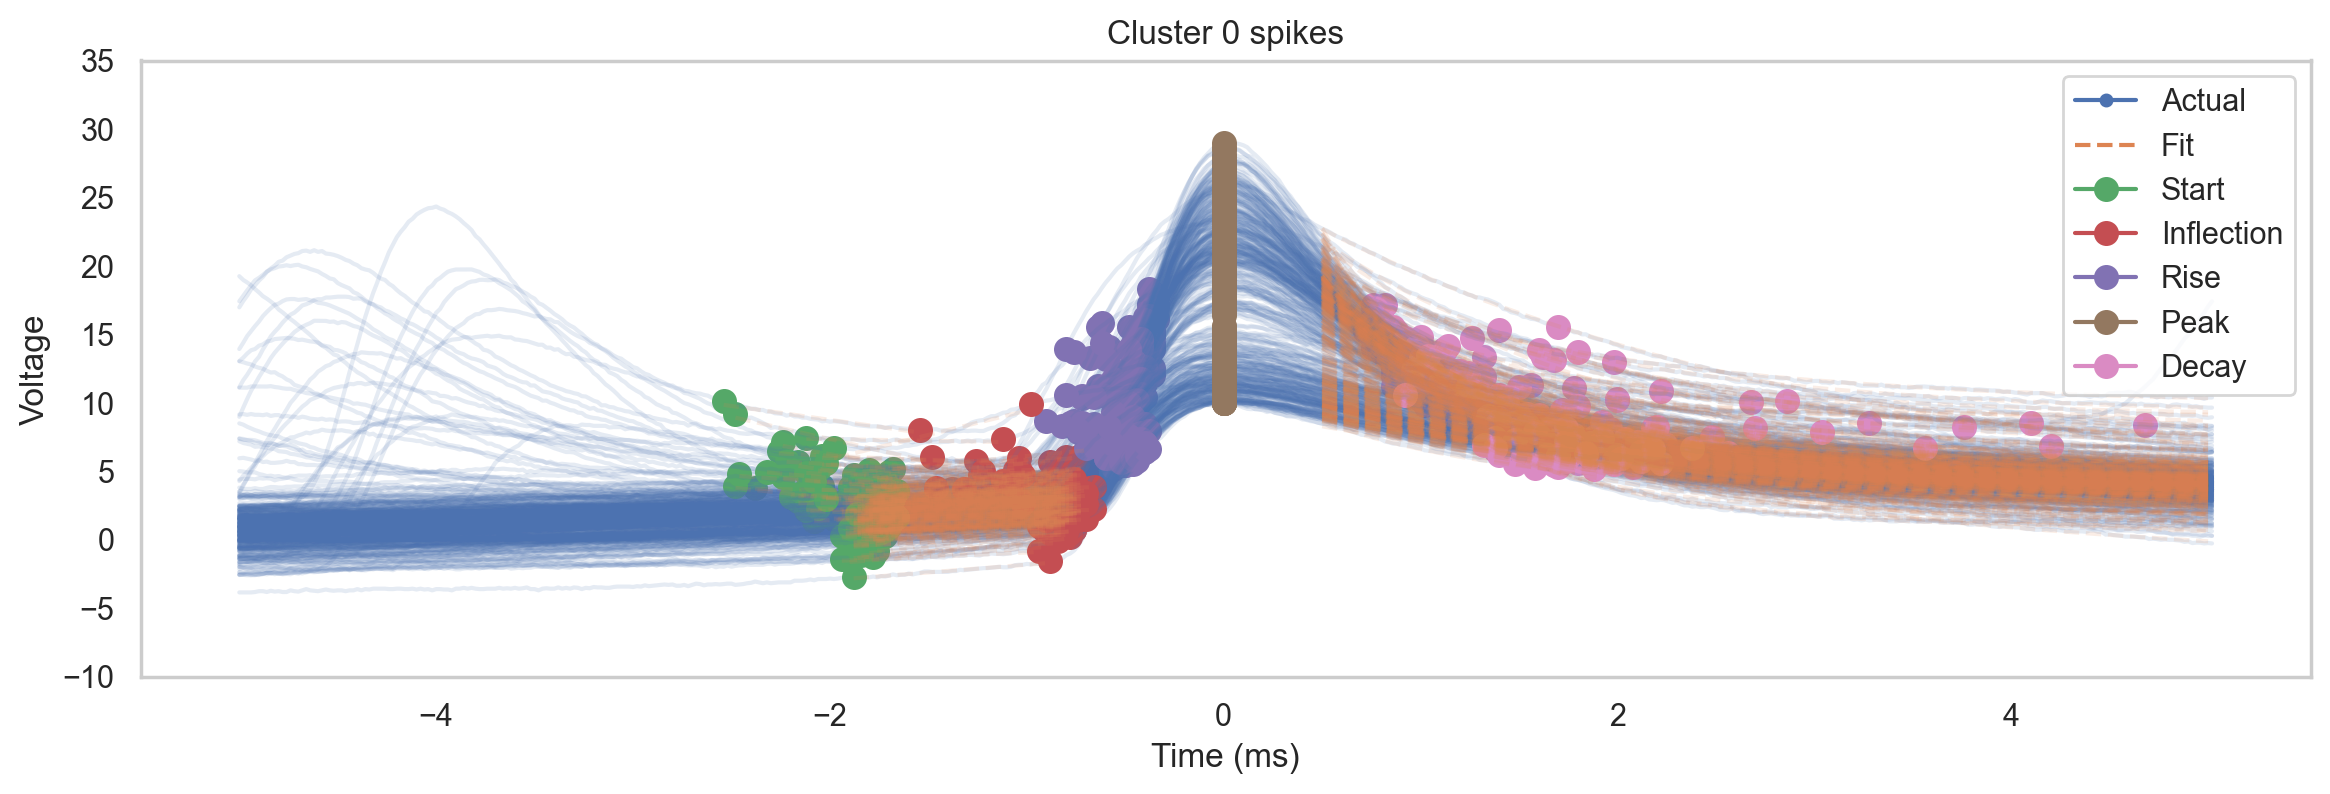

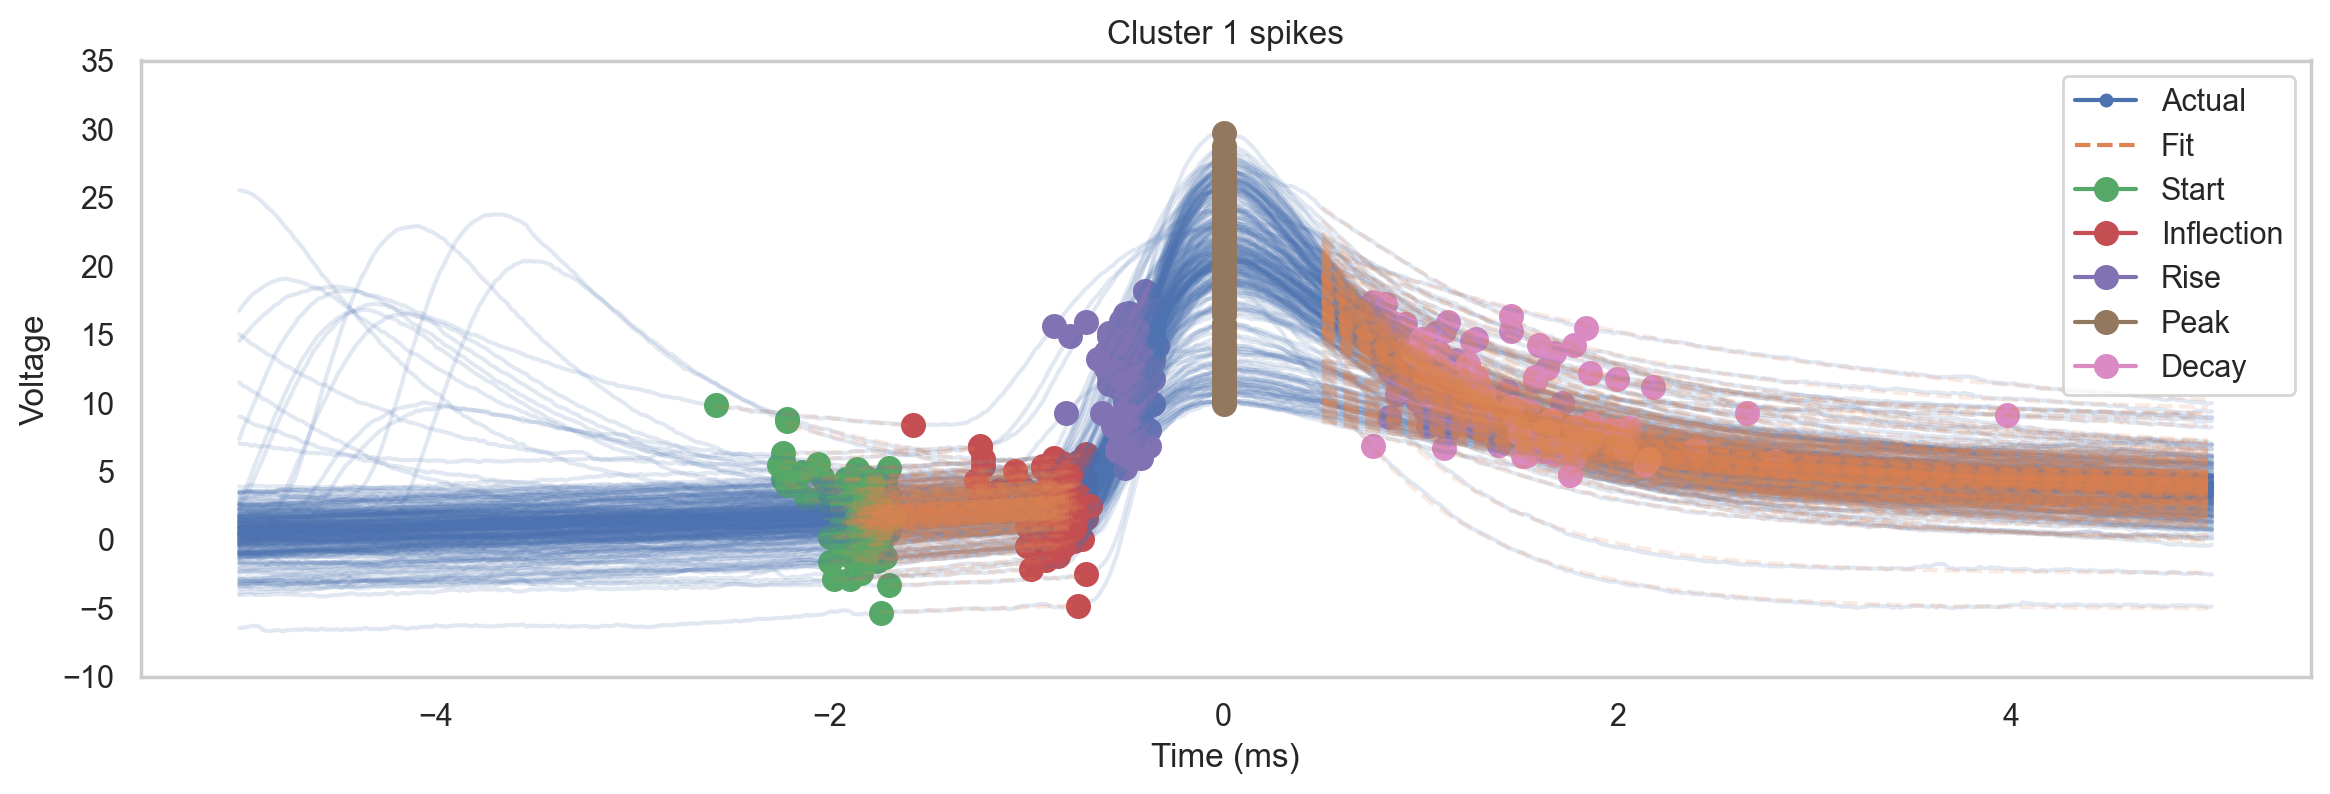

In [24]:
# Plot spikes for Cluster 0
sp.plot(inds=original_indices_cluster_0, mode='full', show_points=True)
plt.title("Cluster 0 spikes")
plt.ylim(-10, 35)
plt.show()

# Plot spikes for Cluster 1
sp.plot(inds=original_indices_cluster_1, mode='full', show_points=True)
plt.title("Cluster 1 spikes")
plt.ylim(-10, 35)

plt.show()

In [25]:
# Standardize features
scaler_0 = StandardScaler()
features_cluster_0_scaled = scaler_0.fit_transform(features_cluster_0)

scaler_1 = StandardScaler()
features_cluster_1_scaled = scaler_1.fit_transform(features_cluster_1)

# Split data into training and test sets
X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(features_cluster_0_scaled, target_cluster_0, test_size=0.2, random_state=42)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(features_cluster_1_scaled, target_cluster_1, test_size=0.2, random_state=42)

# Function to train the model with progress tracking
def train_model_with_progress(X_train, y_train, max_iter=1000):
    model = Ridge(solver='saga', max_iter=1, random_state=42)
    progress_bar = tqdm(range(max_iter), desc="Training Ridge Regression")
    for _ in progress_bar:
        model.max_iter += 1
        model.fit(X_train, y_train)
    return model

# Train models with progress tracking
start_time = time.time()
model_0 = train_model_with_progress(X_train_0, y_train_0)
print("Training time for model_0:", time.time() - start_time)

start_time = time.time()
model_1 = train_model_with_progress(X_train_1, y_train_1)
print("Training time for model_1:", time.time() - start_time)

# Predict and calculate mean squared error
predictions_0 = model_0.predict(X_test_0)
mse_0 = mean_squared_error(y_test_0, predictions_0)
print(f'Mean Squared Error for Cluster 0: {mse_0}')

predictions_1 = model_1.predict(X_test_1)
mse_1 = mean_squared_error(y_test_1, predictions_1)
print(f'Mean Squared Error for Cluster 1: {mse_1}')

Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for model_0: 2.7676076889038086


Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for model_1: 2.5234150886535645
Mean Squared Error for Cluster 0: 0.04306573803740732
Mean Squared Error for Cluster 1: 0.09156973637669626


In [26]:
#rsq values
r2_0 = r2_score(y_test_0, predictions_0)
r2_1 = r2_score(y_test_1, predictions_1)

print(f'R-squared for Cluster 0: {r2_0}')

print(f'R-squared for Cluster 1: {r2_1}')

R-squared for Cluster 0: -0.04688961882362075
R-squared for Cluster 1: 0.15555686923398004


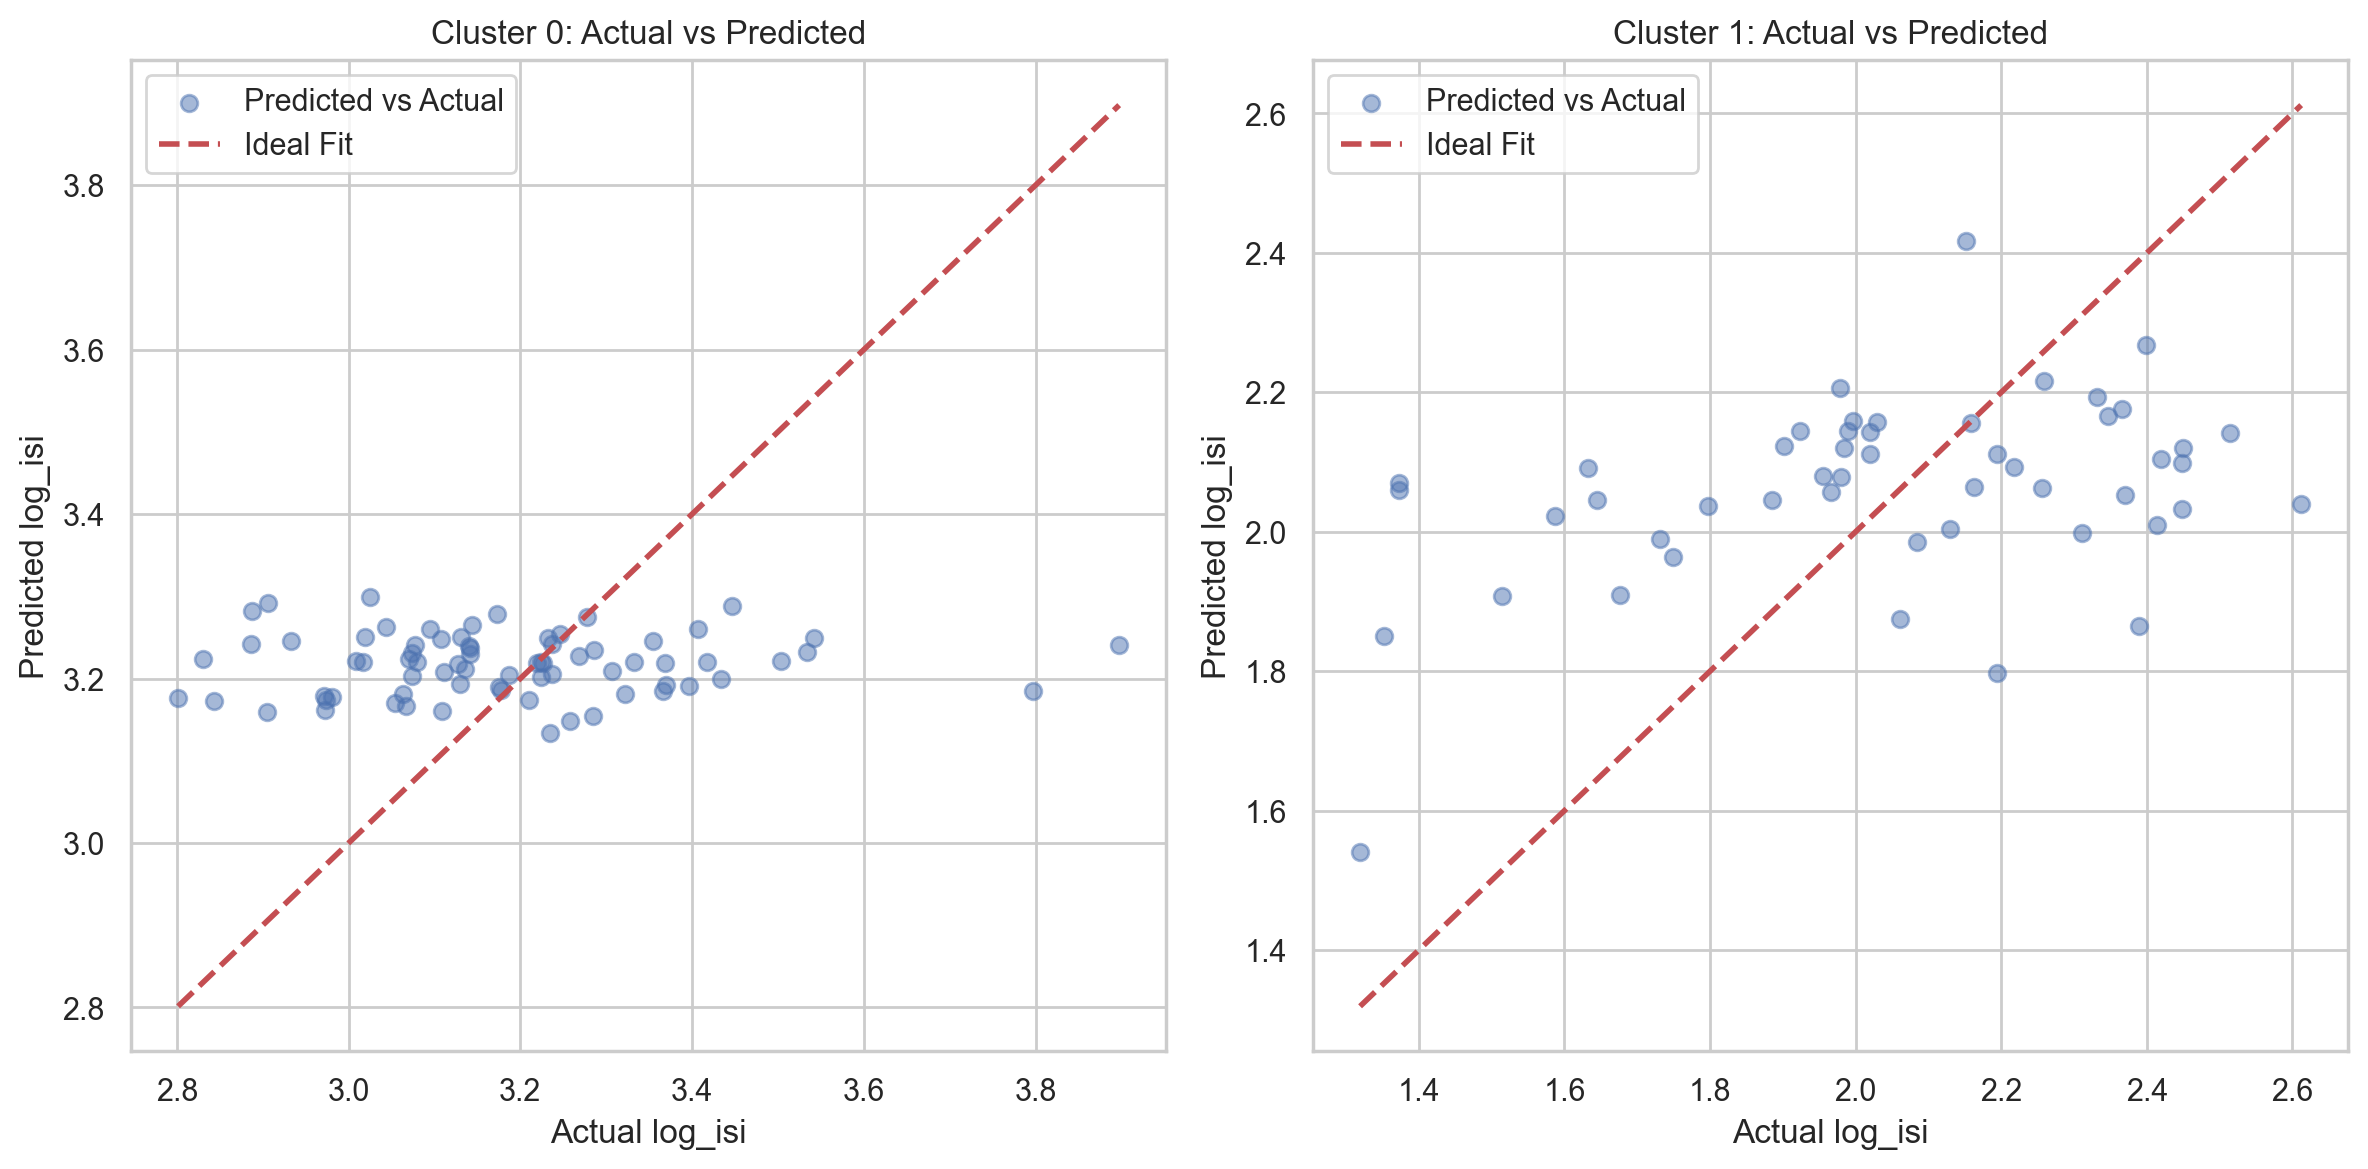

In [27]:
# Visualize the results

# Plotting actual vs predicted values for Cluster 0
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test_0, predictions_0, alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test_0.min(), y_test_0.max()], [y_test_0.min(), y_test_0.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual log_isi')
plt.ylabel('Predicted log_isi')
plt.title('Cluster 0: Actual vs Predicted')
plt.legend()
plt.grid(True)

# Plotting actual vs predicted values for Cluster 1
plt.subplot(1, 2, 2)
plt.scatter(y_test_1, predictions_1, alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test_1.min(), y_test_1.max()], [y_test_1.min(), y_test_1.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual log_isi')
plt.ylabel('Predicted log_isi')
plt.title('Cluster 1: Actual vs Predicted')
plt.legend()
plt.grid(True)

plt.tight_layout()

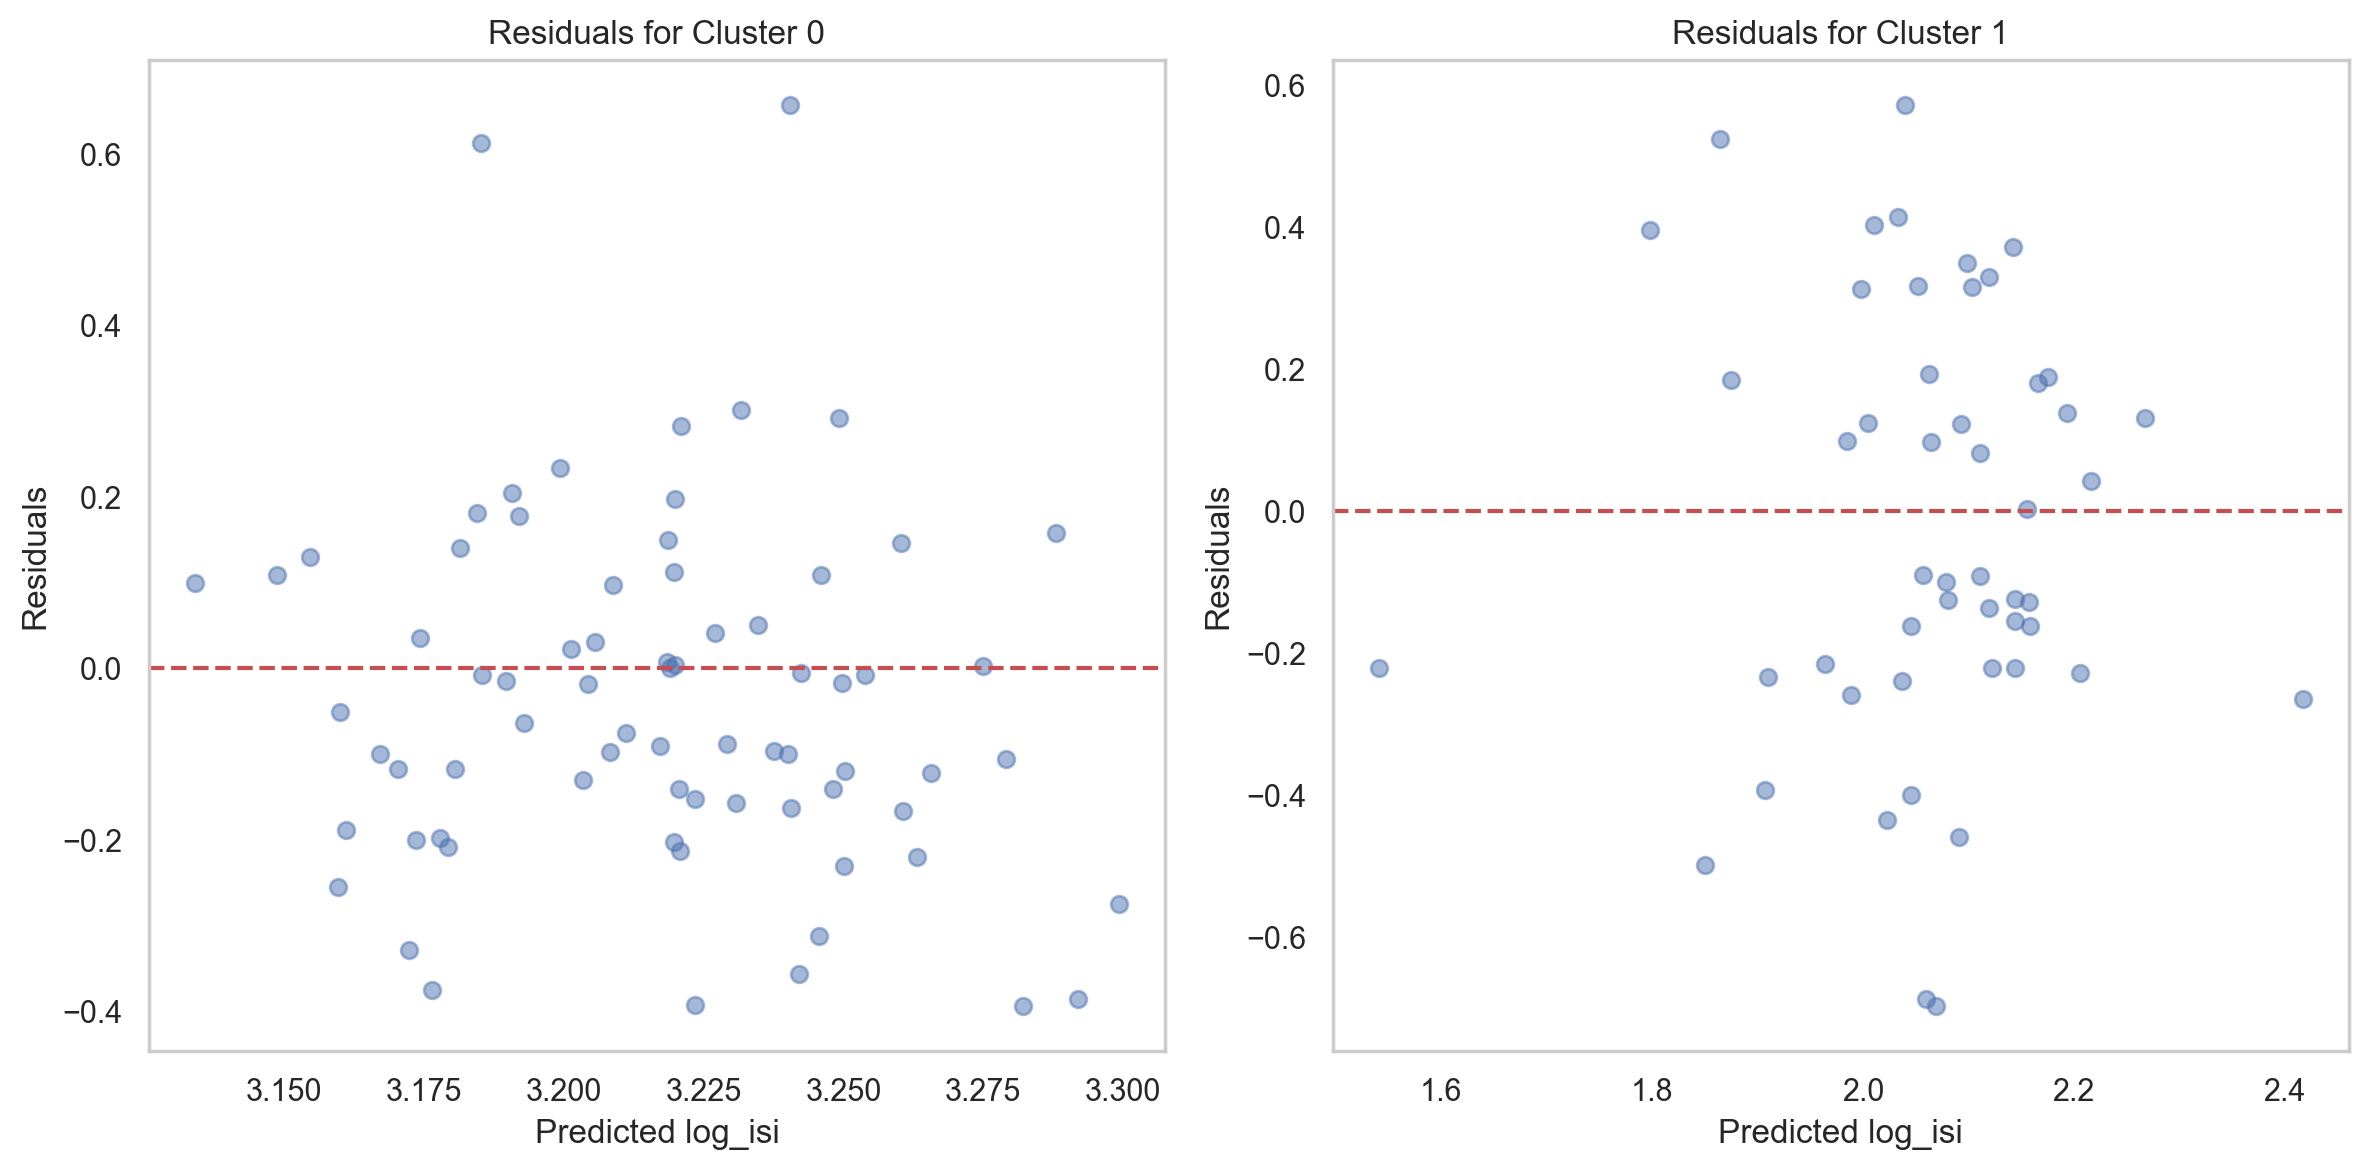

In [28]:
# Calculate residuals
residuals_0 = y_test_0 - predictions_0
residuals_1 = y_test_1 - predictions_1

# Plot residuals for Cluster 0
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(predictions_0, residuals_0, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted log_isi')
plt.ylabel('Residuals')
plt.title('Residuals for Cluster 0')

# Plot residuals for Cluster 1
plt.subplot(1, 2, 2)
plt.scatter(predictions_1, residuals_1, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted log_isi')
plt.ylabel('Residuals')
plt.title('Residuals for Cluster 1')

plt.tight_layout()
plt.show()

In [29]:
### Feature importance

num_features_0 = features_cluster_0.shape[1]
num_features_1 = features_cluster_1.shape[1]

features_0 = [f'Feature_{i}' for i in range(num_features_0)]
features_1 = [f'Feature_{i}' for i in range(num_features_1)]

# Extract coefficients from the trained models
coefficients_0 = model_0.coef_
coefficients_1 = model_1.coef_

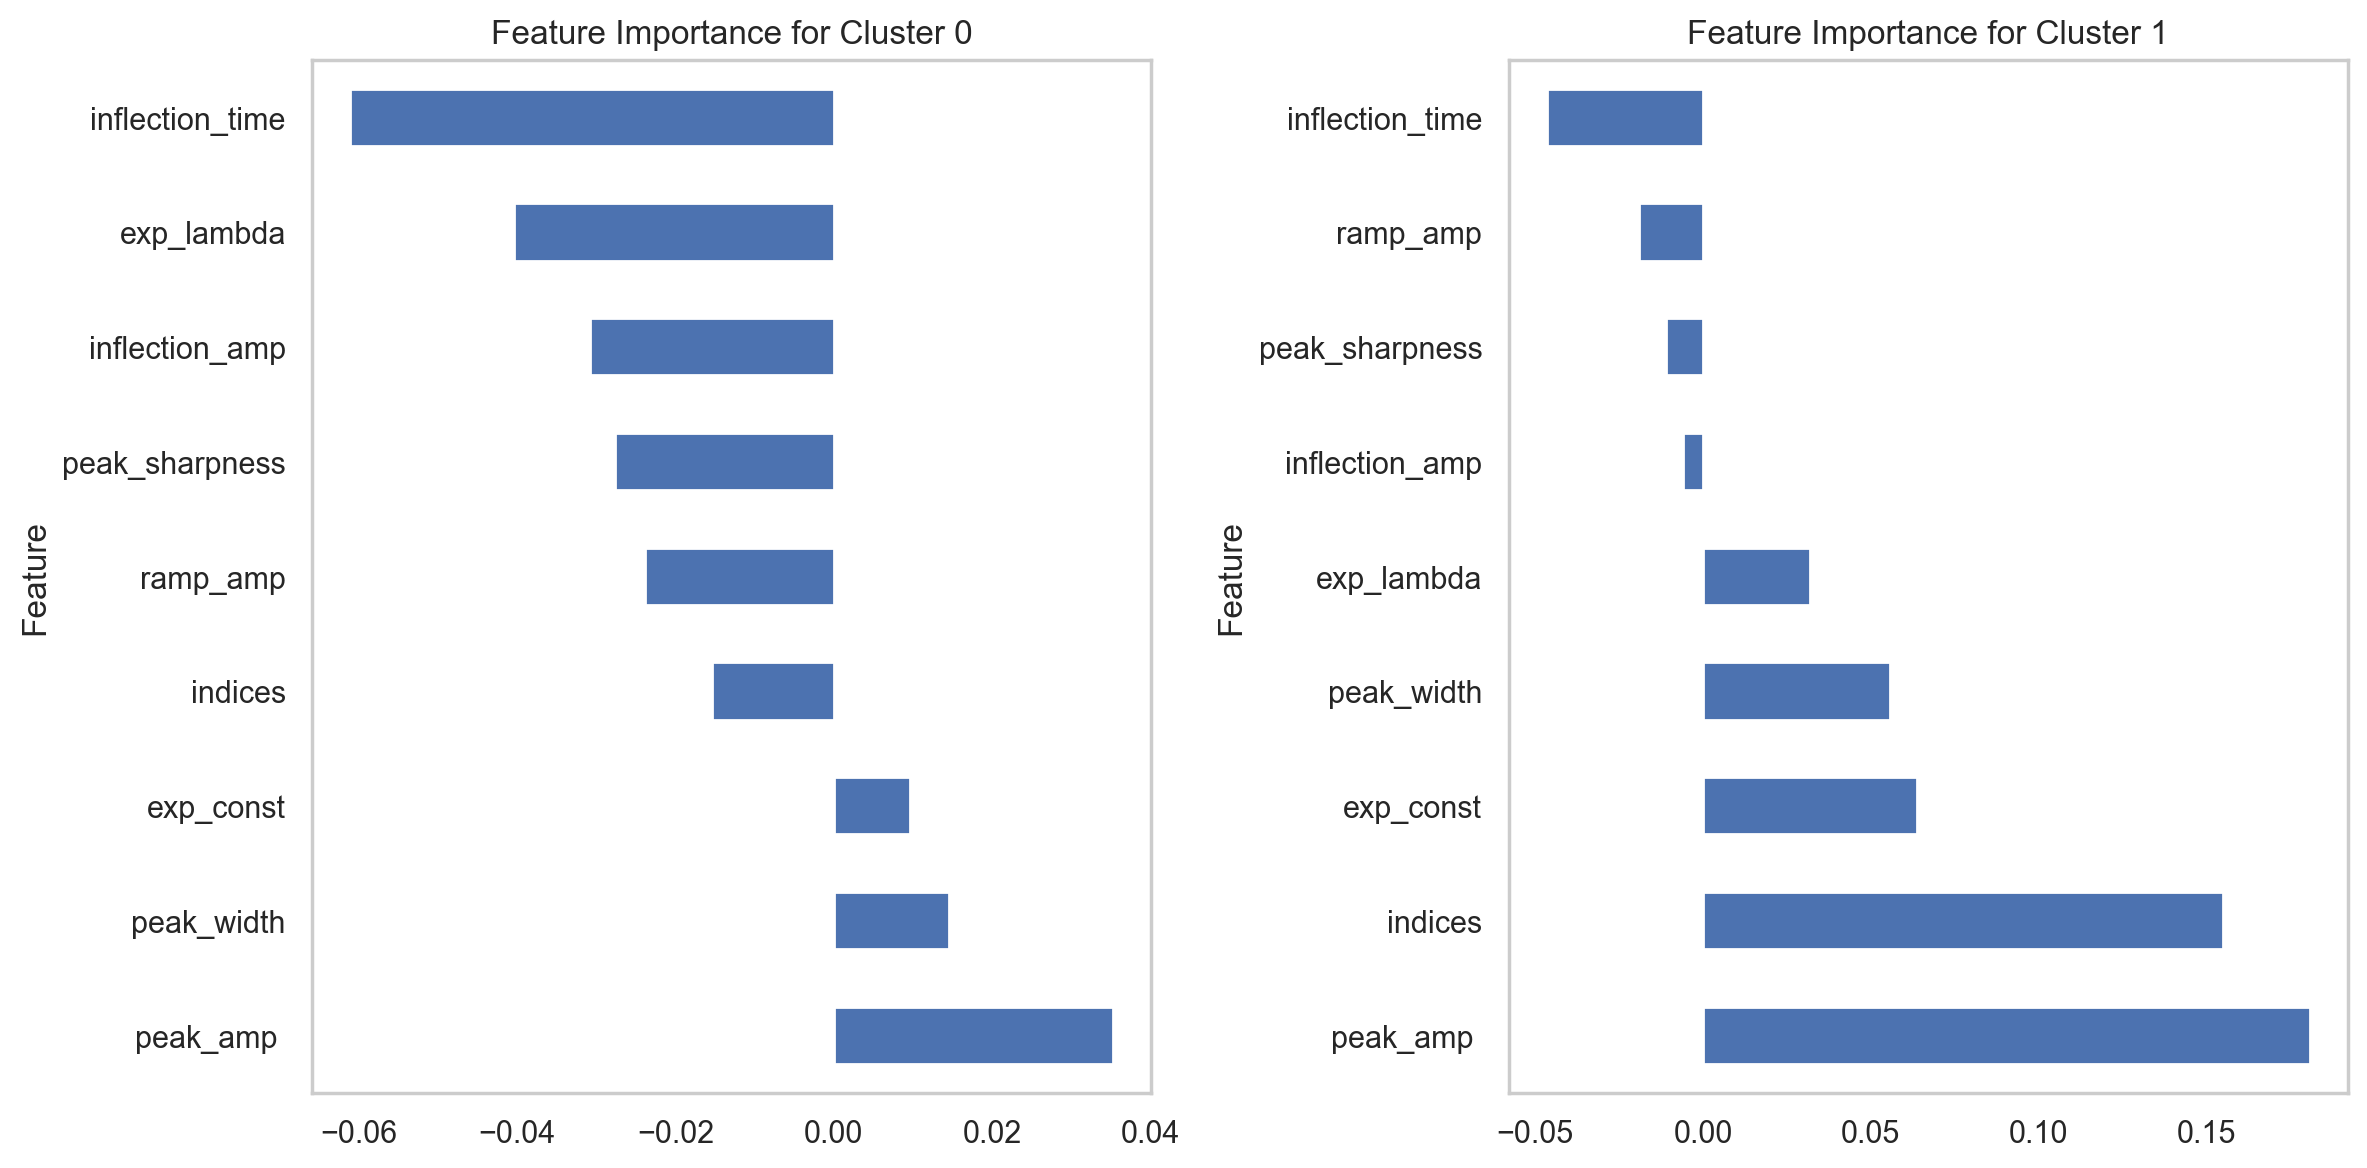

In [30]:
# Assuming you have the actual feature names
actual_feature_names = ['ramp_amp', 'inflection_time', 	'inflection_amp', 	'peak_amp ',	'peak_width', 	'peak_sharpness', 	'exp_lambda', 	'exp_const', 'indices']  # replace with your actual feature names


# Create DataFrames for feature importance
feature_importance_0 = pd.DataFrame({
    'Feature': actual_feature_names,
    'Importance': coefficients_0
})

feature_importance_1 = pd.DataFrame({
    'Feature': actual_feature_names,
    'Importance': coefficients_1
})

# Plot feature importance for Cluster 0
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
feature_importance_0.sort_values(by='Importance', ascending=False).plot.barh(x='Feature', y='Importance', ax=plt.gca(), legend=False)
plt.title('Feature Importance for Cluster 0')

# Plot feature importance for Cluster 1
plt.subplot(1, 2, 2)
feature_importance_1.sort_values(by='Importance', ascending=False).plot.barh(x='Feature', y='Importance', ax=plt.gca(), legend=False)
plt.title('Feature Importance for Cluster 1')

plt.tight_layout()
plt.show()


### Run regression without splitting into clusters 

In [31]:
# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)


In [32]:
# Train model with progress tracking
start_time = time.time()
model = train_model_with_progress(X_train, y_train)
print("Training time for the model:", time.time() - start_time)

# Predict and calculate mean squared error and R-squared
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for the model: 2.939002752304077
Mean Squared Error: 0.3612366419474277
R-squared: 0.006195202805256761


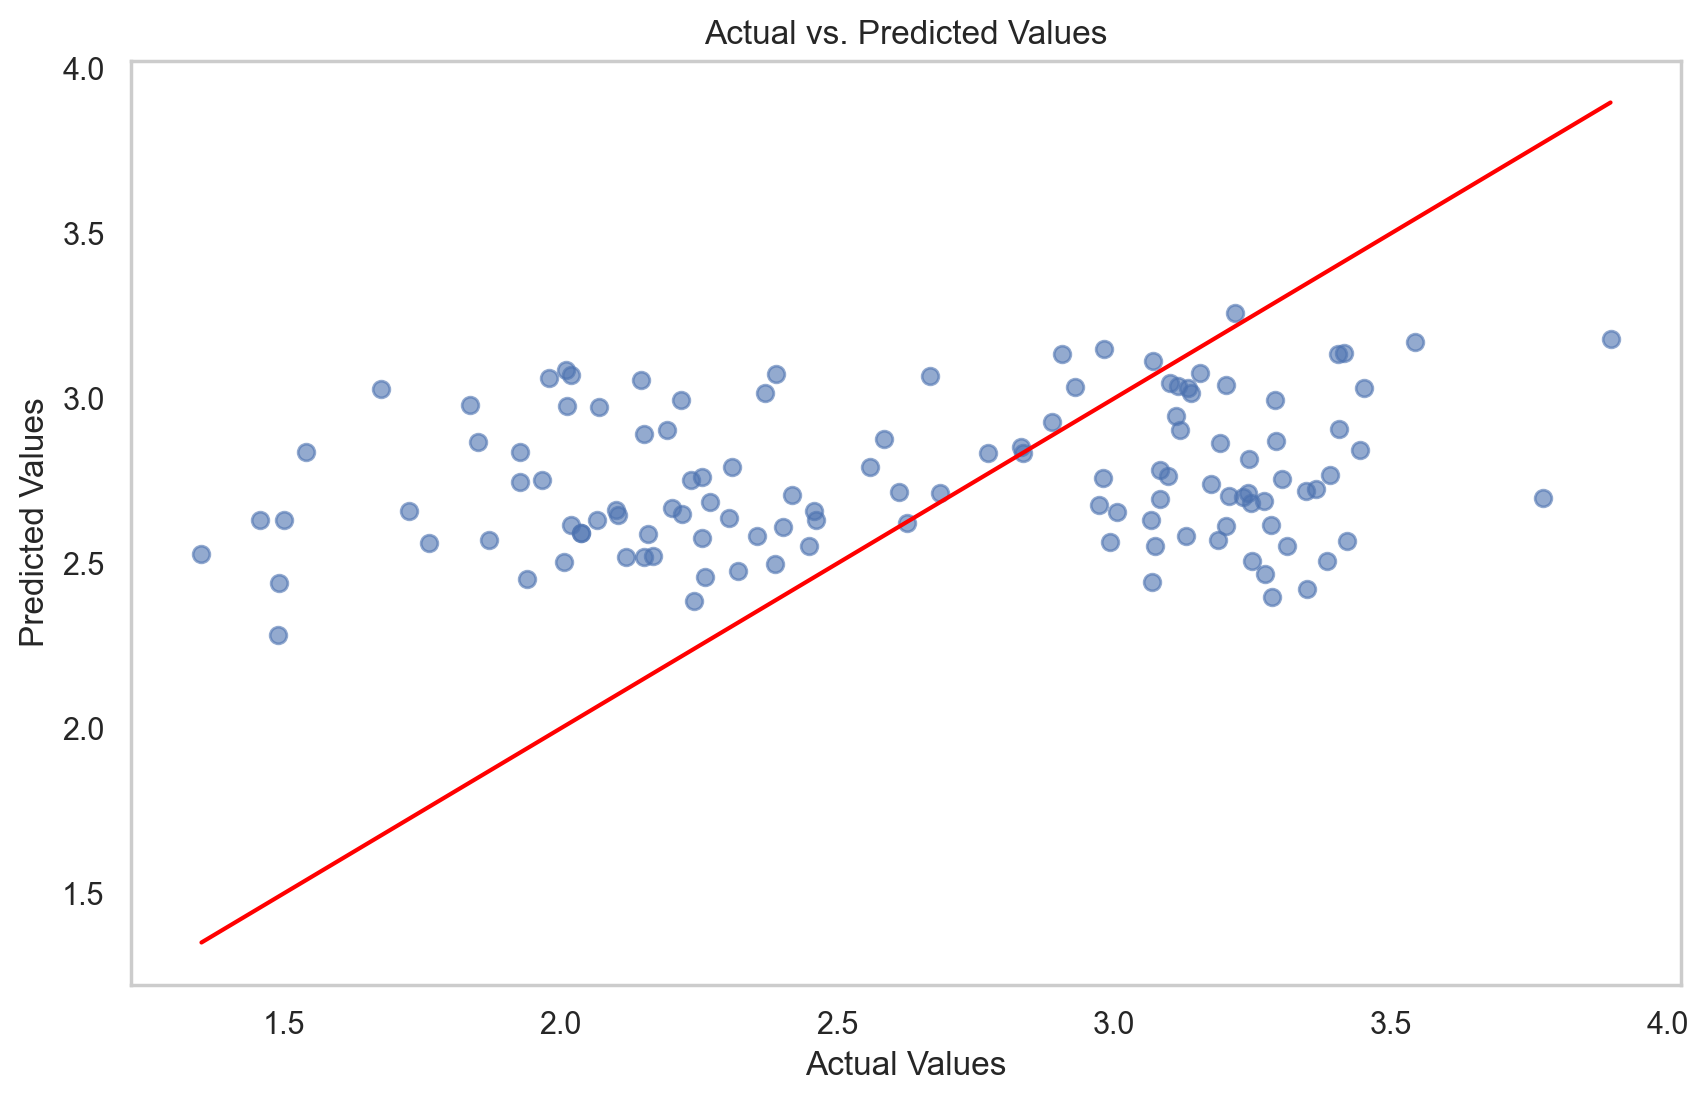

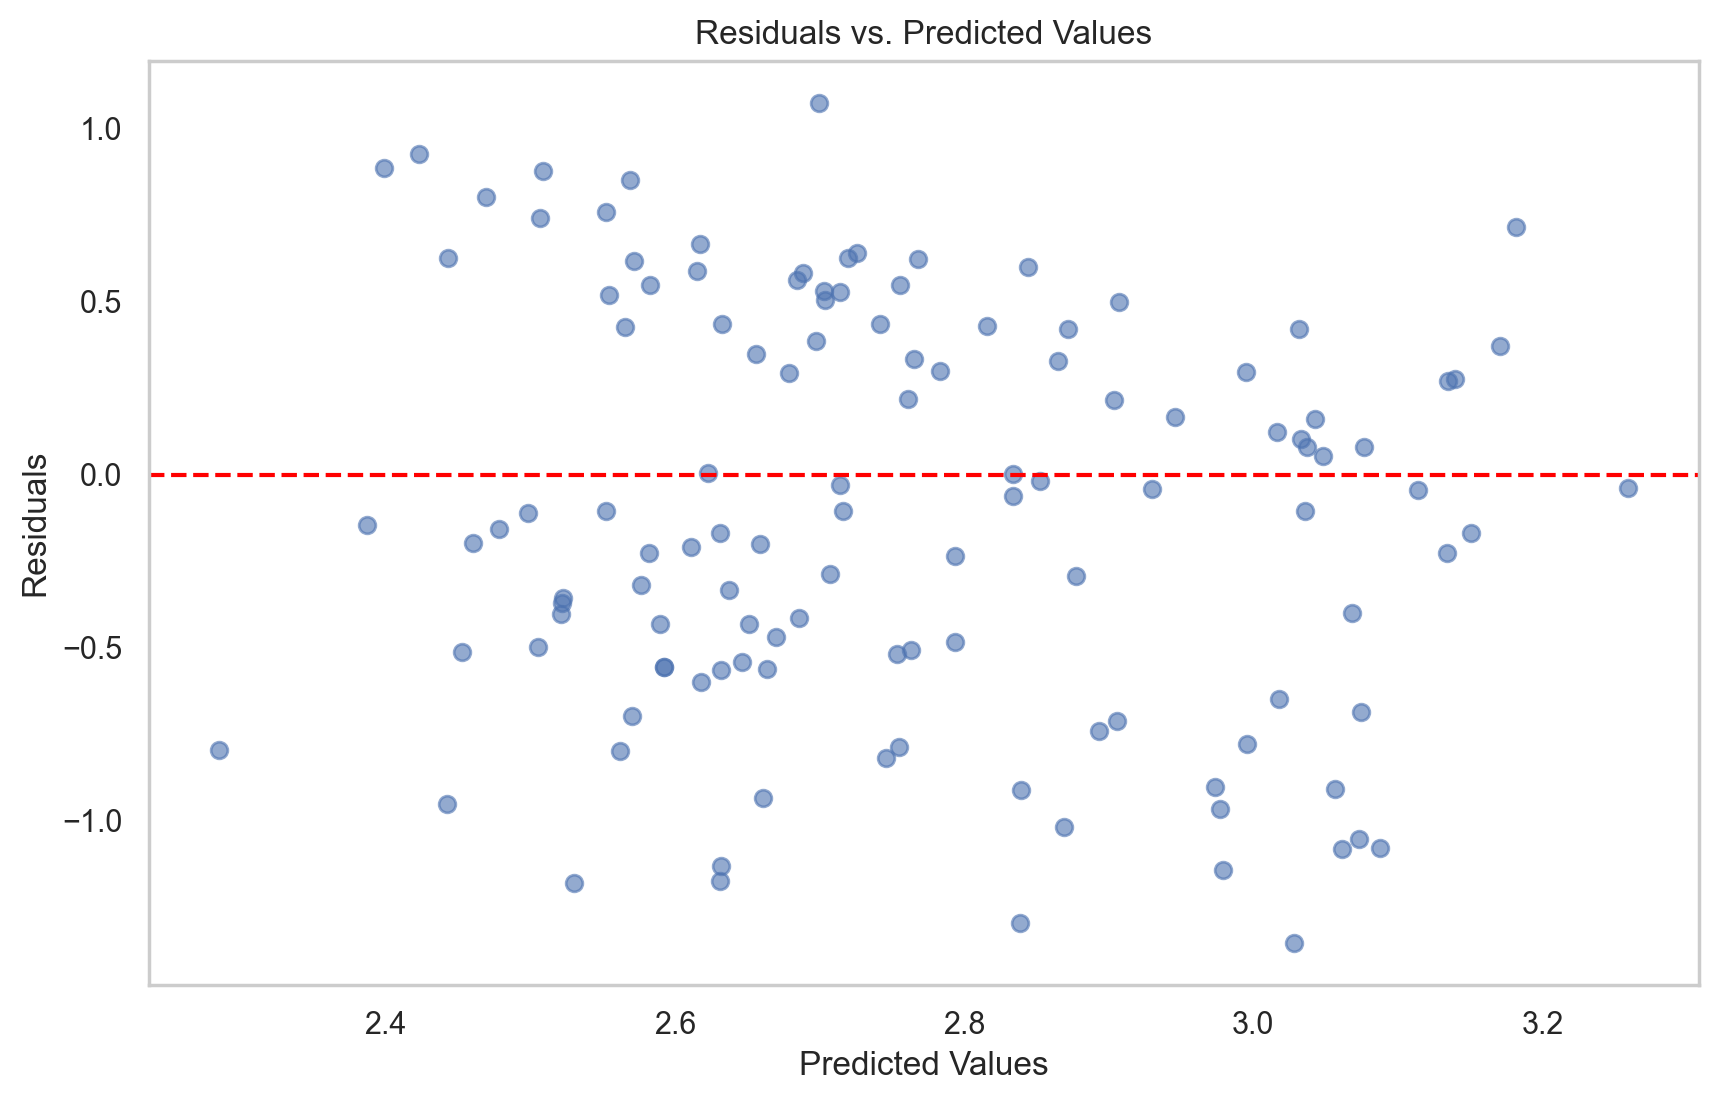

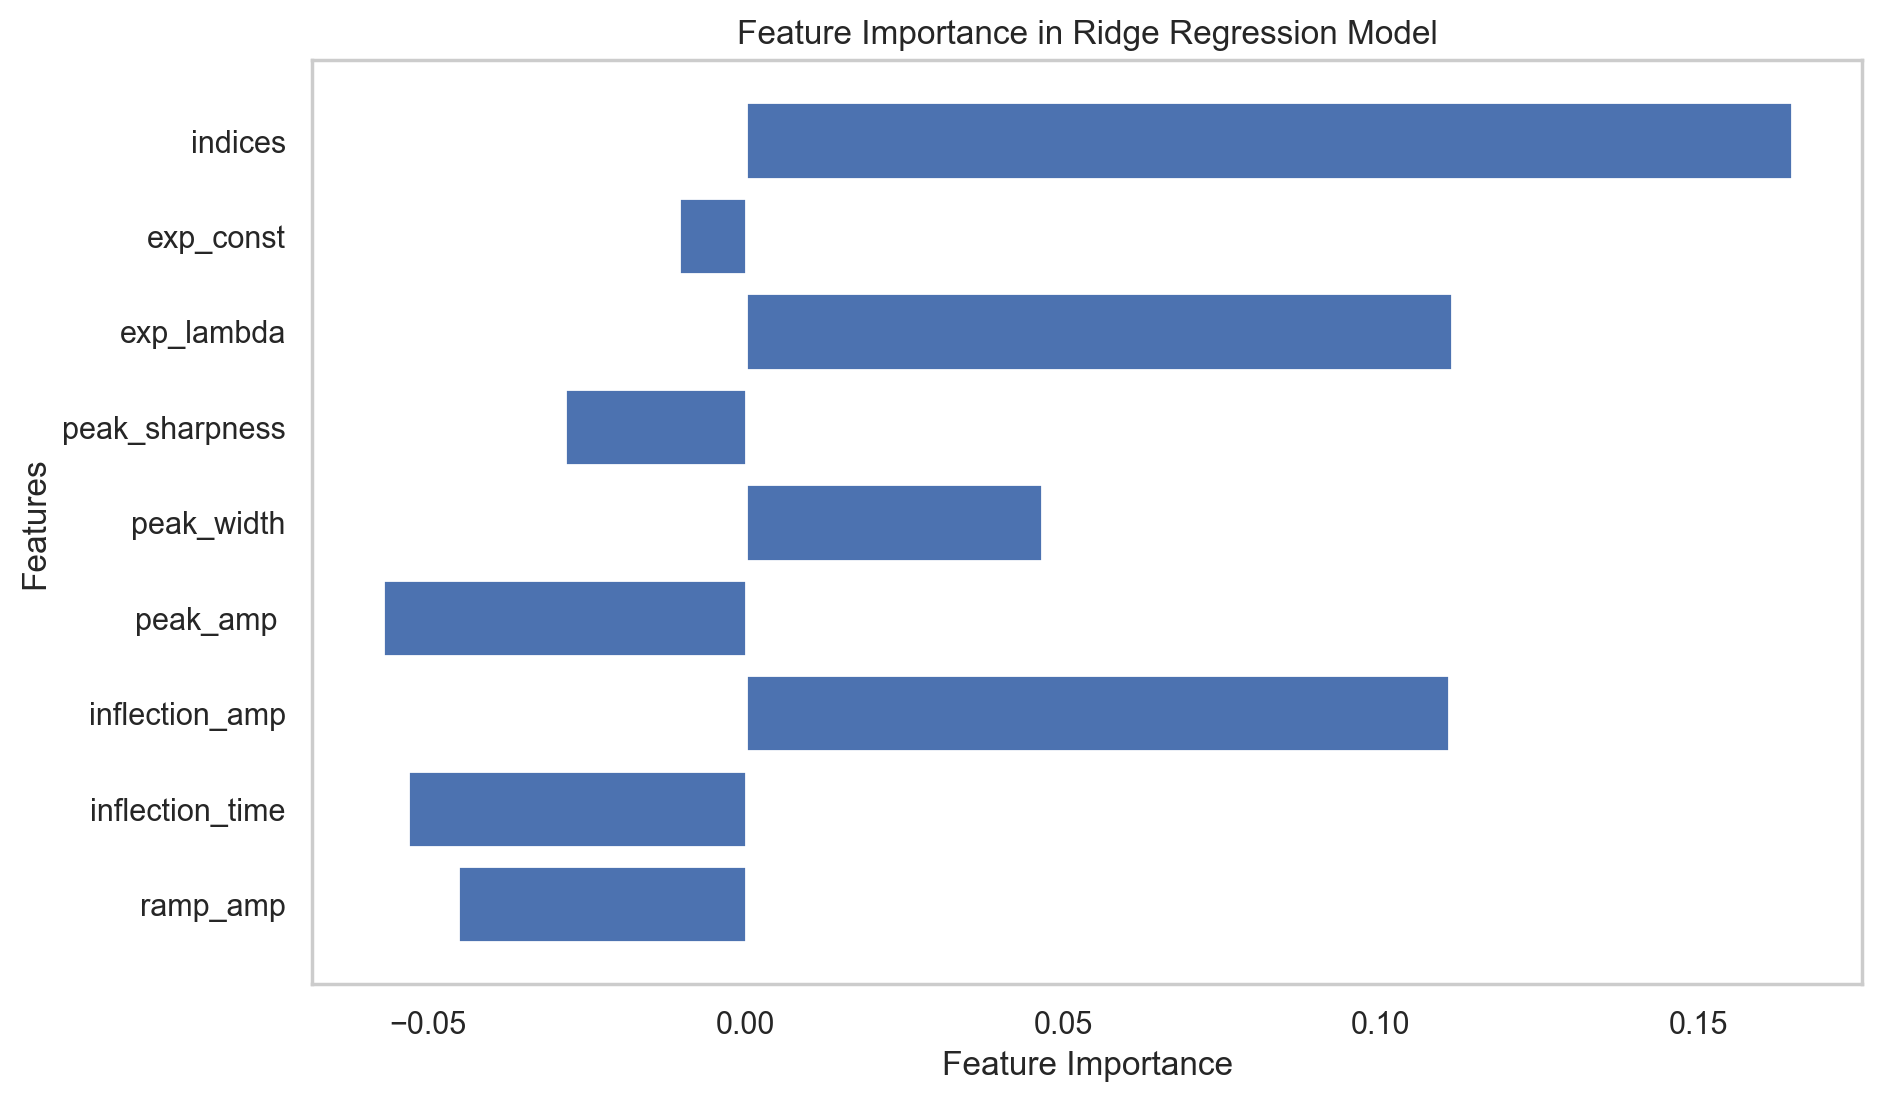

In [33]:
# Visualization of predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # 45-degree line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

# Visualization of residuals
residuals = y_test - predictions
plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

# Feature importance
feature_importance = model.coef_

actual_feature_names = ['ramp_amp', 'inflection_time', 	'inflection_amp', 	'peak_amp ',	'peak_width', 	'peak_sharpness', 	'exp_lambda', 	'exp_const', 'indices']  # replace with your actual feature names

plt.figure(figsize=(10, 6))
plt.barh(np.arange(len(feature_importance)), feature_importance)
plt.yticks(np.arange(len(feature_importance)), actual_feature_names )  # Replace with actual feature names
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Ridge Regression Model')
plt.show()


### Stats - compare models  - not significantly diff based on MSE values, but differences (no stats) in rsq for the models 

In [34]:
# Predictions and metrics for Cluster 0
predictions_0 = model_0.predict(X_test_0)
mse_0 = mean_squared_error(y_test_0, predictions_0)
r2_0 = r2_score(y_test_0, predictions_0)

# Predictions and metrics for Cluster 1
predictions_1 = model_1.predict(X_test_1)
mse_1 = mean_squared_error(y_test_1, predictions_1)
r2_1 = r2_score(y_test_1, predictions_1)

# Predictions and metrics for the entire dataset
predictions_all = model.predict(X_test)
mse_all = mean_squared_error(y_test, predictions_all)
r2_all = r2_score(y_test, predictions_all)

print(f'MSE for Cluster 0: {mse_0}')
print(f'R² for Cluster 0: {r2_0}')
print(f'MSE for Cluster 1: {mse_1}')
print(f'R² for Cluster 1: {r2_1}')
print(f'MSE for Entire dataset: {mse_all}')
print(f'R² for Entire dataset: {r2_all}')

MSE for Cluster 0: 0.04306573803740732
R² for Cluster 0: -0.04688961882362075
MSE for Cluster 1: 0.09156973637669626
R² for Cluster 1: 0.15555686923398004
MSE for Entire dataset: 0.3612366419474277
R² for Entire dataset: 0.006195202805256761


In [35]:
# Calculate individual prediction errors
errors_0 = y_test_0 - predictions_0
errors_1 = y_test_1 - predictions_1
errors_all = y_test - predictions_all

In [36]:
from scipy.stats import f_oneway

# Perform ANOVA using the prediction errors
F_mse, p_value_mse = f_oneway(errors_0, errors_1, errors_all)

print(f'ANOVA results for MSE: F-statistic = {F_mse}, p-value = {p_value_mse}')



ANOVA results for MSE: F-statistic = 0.9046492792458942, p-value = 0.40604785255427467


In [37]:
from scipy.stats import ttest_ind

# T-tests for MSEs
t_mse_0_1, p_mse_0_1 = ttest_ind(errors_0, errors_1)
t_mse_0_all, p_mse_0_all = ttest_ind(errors_0, errors_all)
t_mse_1_all, p_mse_1_all = ttest_ind(errors_1, errors_all)

print(f'T-test results for MSE between Cluster 0 and Cluster 1: t-statistic = {t_mse_0_1}, p-value = {p_mse_0_1}')
print(f'T-test results for MSE between Cluster 0 and entire dataset: t-statistic = {t_mse_0_all}, p-value = {p_mse_0_all}')
print(f'T-test results for MSE between Cluster 1 and entire dataset: t-statistic = {t_mse_1_all}, p-value = {p_mse_1_all}')


T-test results for MSE between Cluster 0 and Cluster 1: t-statistic = -0.32372808374516665, p-value = 0.7467027763235532
T-test results for MSE between Cluster 0 and entire dataset: t-statistic = 0.9940755251537728, p-value = 0.321430775208624
T-test results for MSE between Cluster 1 and entire dataset: t-statistic = 0.9772804393446818, p-value = 0.32981898190343484


### Are the spikes in the cluster with shorter ISIs burst spikes?

Mean ISI for Cluster 0: 3.2060270465299783
Mean ISI for Cluster 1: 2.0709054393159545
Cluster with shorter ISIs: 1
Indices of spikes with shorter ISIs: [  0   2   5   6   7  12  13  15  16  19  21  22  23  25  26  28  30  31
  33  34  36  37  39  42  43  44  46  48  49  51  53  54  56  57  59  62
  63  65  67  69  71  72  75  77  78  80  82  85  87  89  92  96  98 100
 101 103 105 106 108 110 112 114 116 117 120 127 131 134 140 143 148 150
 162 165 174 177 180 182 183 185 186 187 189 190 191 193 194 196 197 199
 202 203 204 205 206 208 211 213 214 215 217 218 220 222 224 226 228 229
 230 231 232 233 234 235 237 238 241 243 244 245 246 247 248 249 250 253
 254 256 259 260 262 265 267 269 270 272 274 277 278 280 283 284 286 287
 289 291 294 297 300 304 307 309 311 312 314 315 318 319 320 322 323 325
 326 328 330 332 334 335 336 338 345 347 349 351 354 355 358 360 362 364
 366 368 369 371 372 374 377 379 380 382 386 388 391 392 393 395 399 402
 404 406 410 411 416 418 421 431 438 446 448 

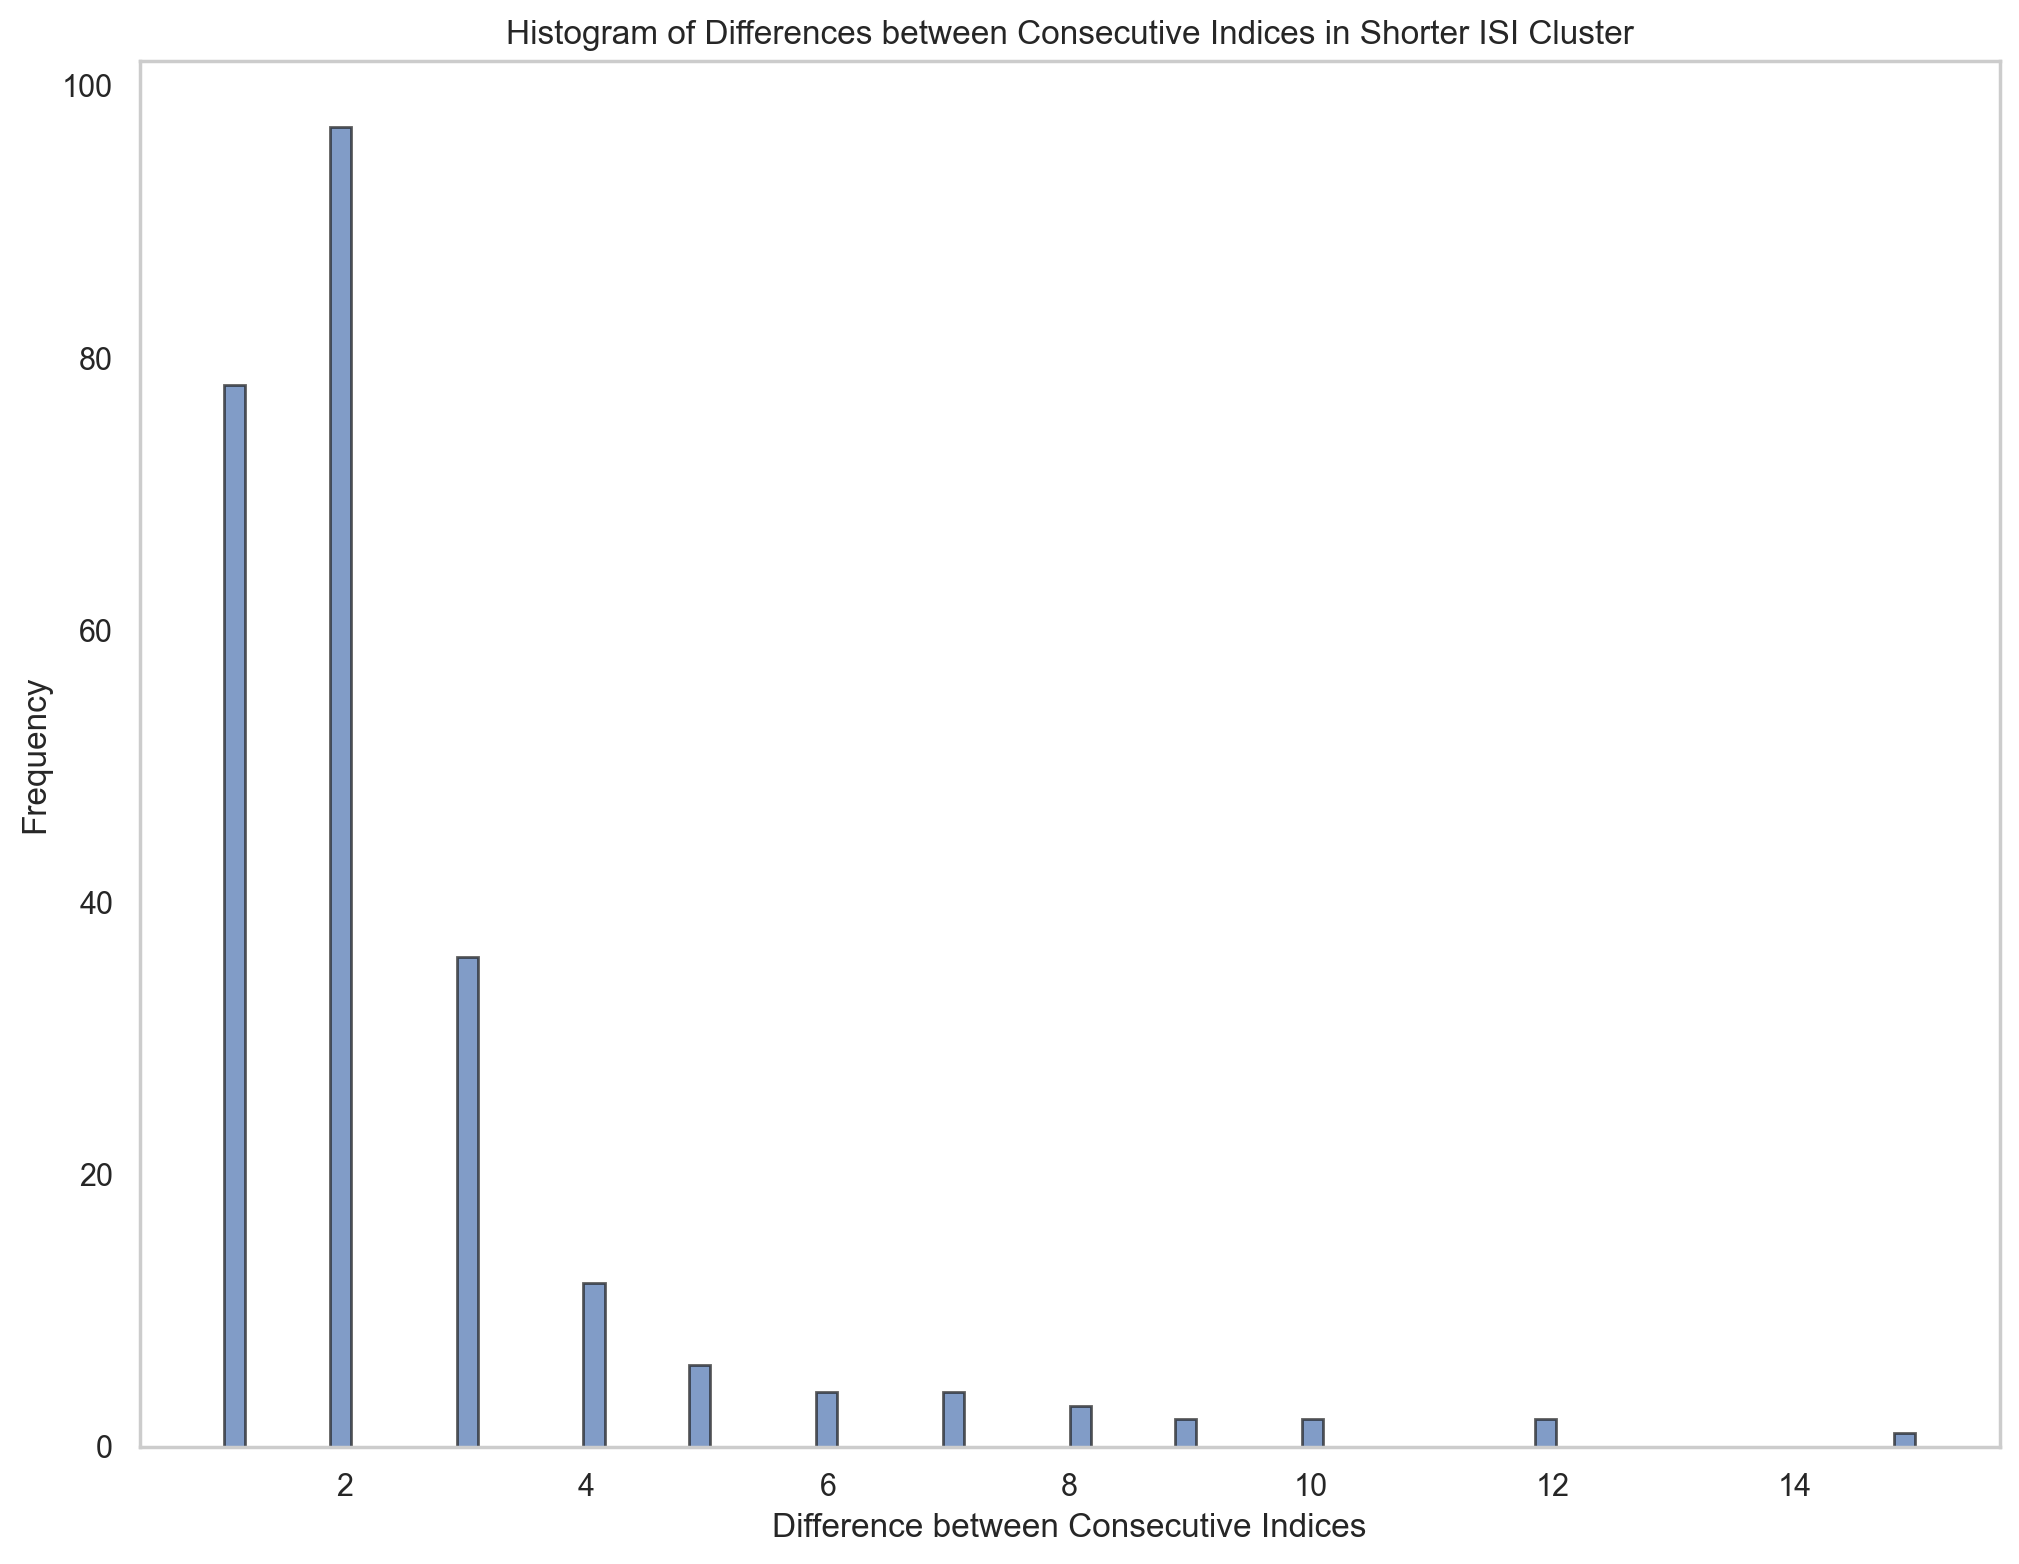

Differences between consecutive indices (longer ISI cluster): [2 1 4 1 1 4 3 3 4 3 2 3 3 3 2 1 4 2 3 2 3 3 2 1 3 2 2 2 3 3 3 2 2 1 2 2 2
 1 2 1 1 2 2 3 2 3 2 2 2 2 3 1 2 1 1 1 1 1 2 1 1 2 1 2 1 1 1 1 2 1 2 1 1 1
 2 2 1 1 1 1 1 1 1 1 1 1 2 1 2 1 1 1 1 1 1 1 2 1 2 1 2 3 4 4 3 3 2 1 6 2 1
 2 4 3 2 2 2 2 9 3 1 2 9 1 3 2 1 3 2 1 2 2 3 2 2 1 3 2 1 3 3 2 2 1 2 1 2 1
 2 1 1 2 1 2 2 3 3 1 4 3 3 2 2 2 4 2 1 1 1 1 3 2 4 1 3 1 2 2 2 2 2 3 3 2 1
 2 3 3 1 2 2 1 4 2 1 1 2 1 2 2 2 1 1 3 1 1 1 2 2 1 2 1 1 1 1 1 1 1 1 2 1 1
 1 1 1 2 1 1 1 1 1 1 2 2 1 1 1 1 1 2 3 1 1 1 1 1 1 3 1 1 1 4 1 2 2 1 1 1 1
 1 1 1 1 1 1 2 1 1 1 2 2 2 1 1 1 3 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 3 2 1 2 1
 1 1 1 1 1 2 2 3 1 1 2 1 1 2 1 1 1 1 5 2 1 1 3 1 2 1 1 2 1 2 1 2 2 1 3 1 3
 2 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 2 1 1 2]


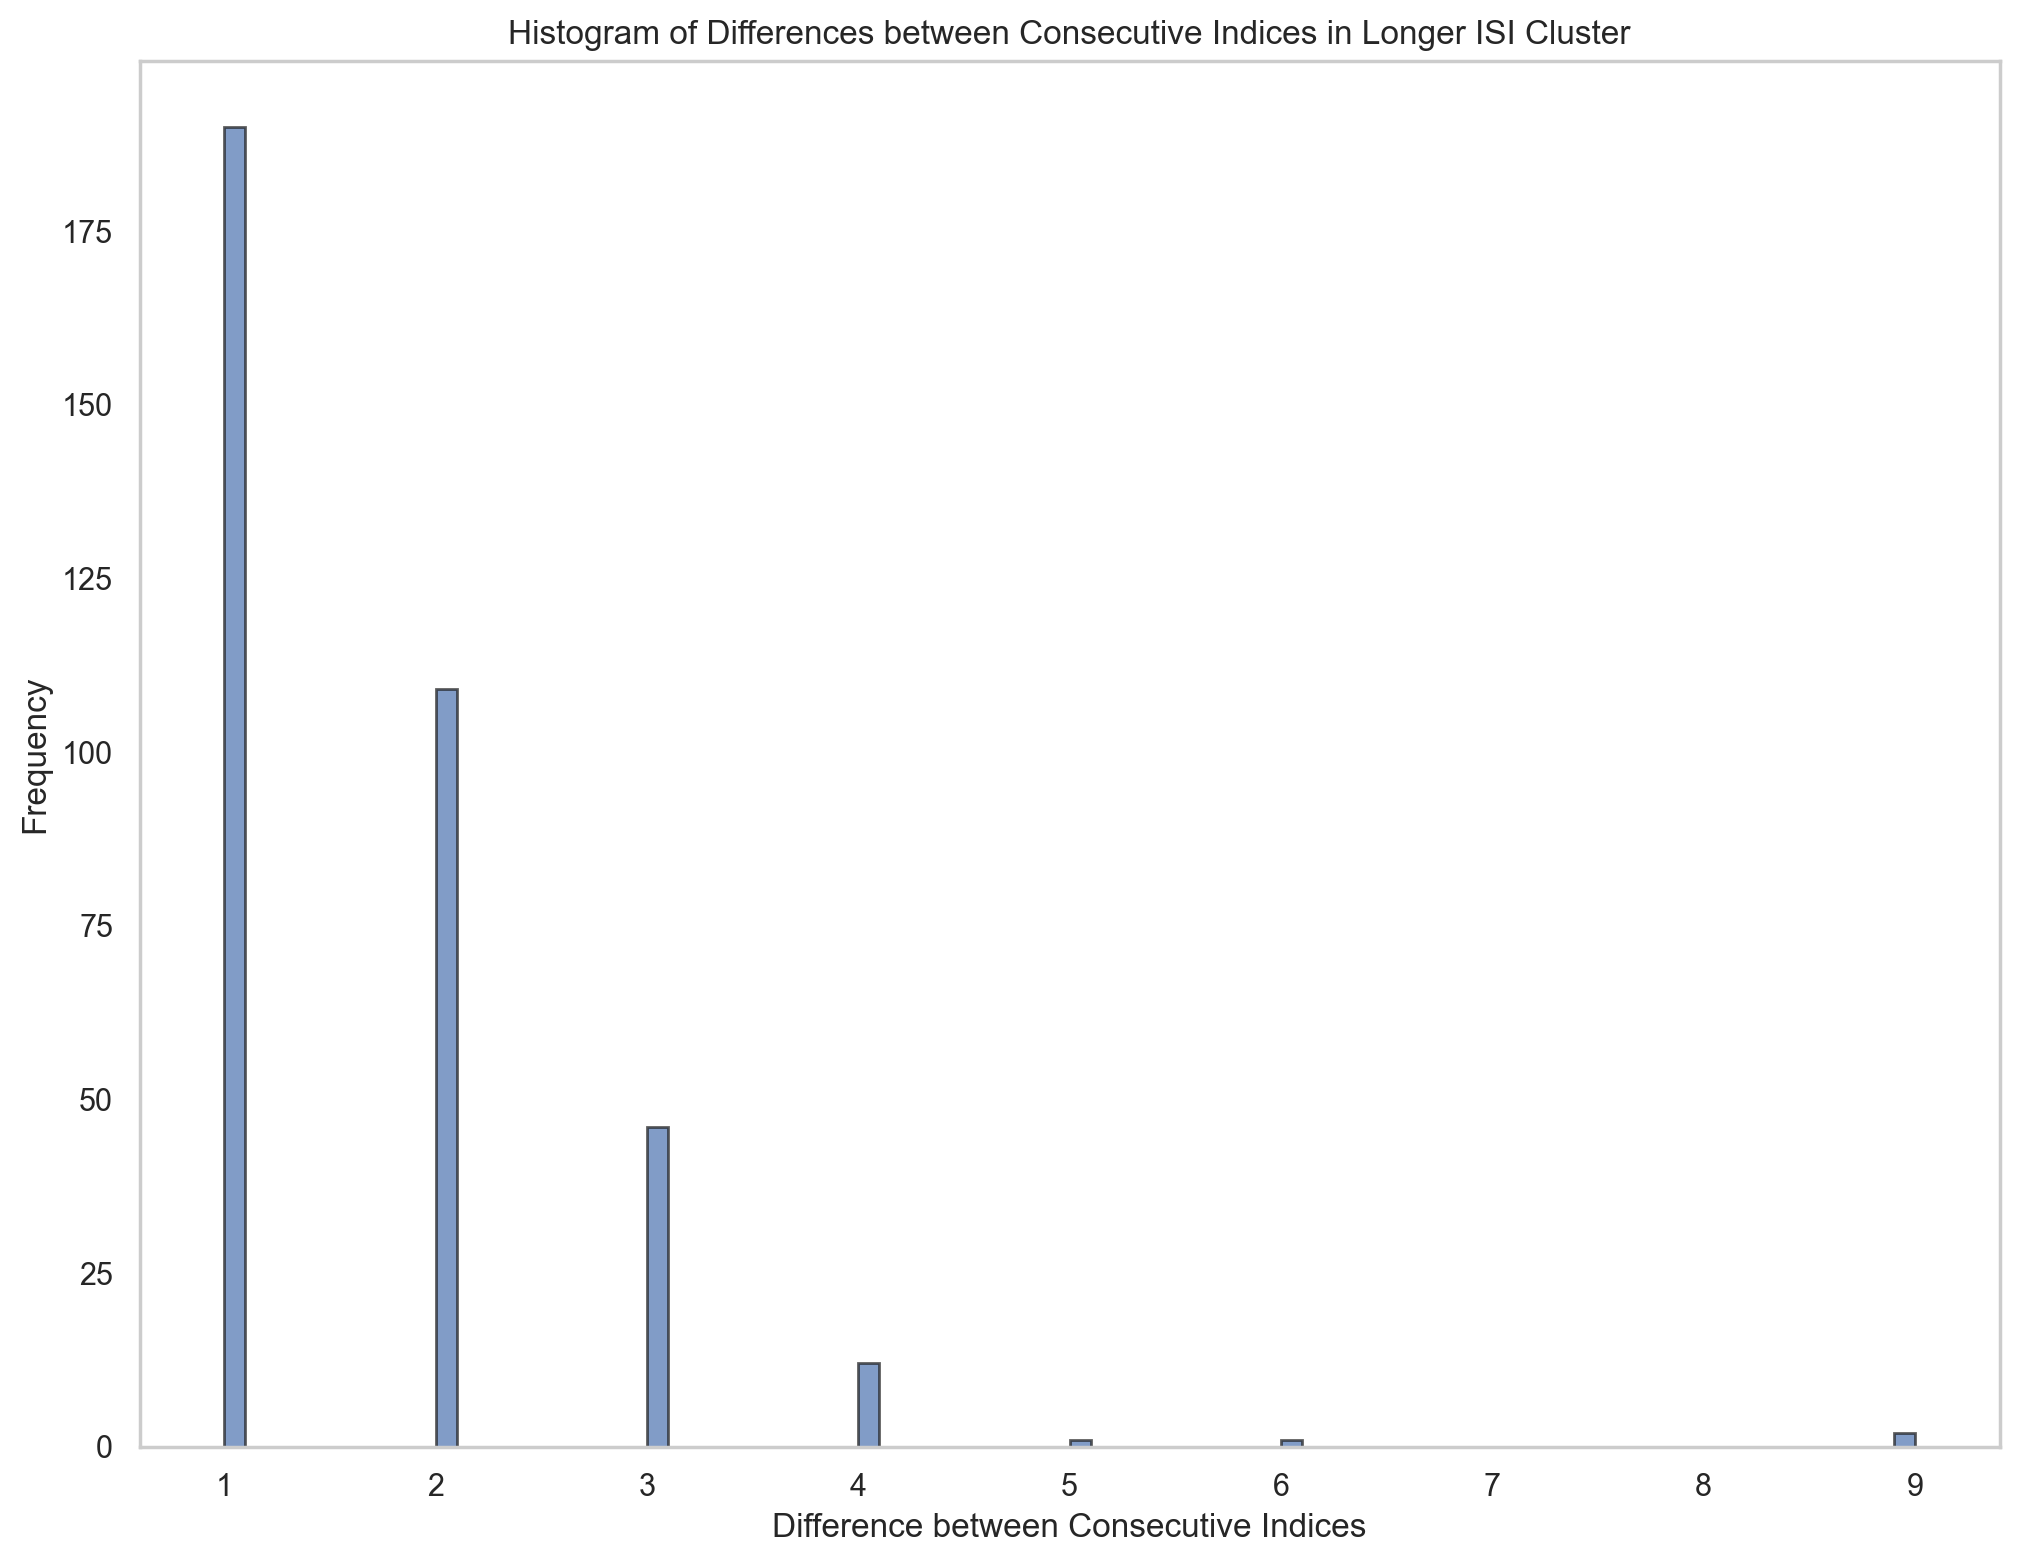

In [38]:
# Add cluster labels to the DataFrame
df_features['cluster'] = clusters

# Split data into clusters
df_cluster_0 = df_features[df_features['cluster'] == 0]
df_cluster_1 = df_features[df_features['cluster'] == 1]

# Determine which cluster has shorter ISIs
mean_isi_cluster_0 = np.mean(df_cluster_0['log_isi'])
mean_isi_cluster_1 = np.mean(df_cluster_1['log_isi'])

print(f"Mean ISI for Cluster 0: {mean_isi_cluster_0}")
print(f"Mean ISI for Cluster 1: {mean_isi_cluster_1}")

# Identify the cluster with shorter ISIs
shorter_isi_cluster = 0 if mean_isi_cluster_0 < mean_isi_cluster_1 else 1
longer_isi_cluster = 1 if shorter_isi_cluster == 0 else 0

print(f"Cluster with shorter ISIs: {shorter_isi_cluster}")

# Extract original indices for both clusters
if shorter_isi_cluster == 0:
    shorter_isi_indices = df_cluster_0['original_index']
    longer_isi_indices = df_cluster_1['original_index']
else:
    shorter_isi_indices = df_cluster_1['original_index']
    longer_isi_indices = df_cluster_0['original_index']

print(f"Indices of spikes with shorter ISIs: {shorter_isi_indices.values}")
print(f"Indices of spikes with longer ISIs: {longer_isi_indices.values}")

# Analyze indices for bursts
# Check if indices are sequential or almost sequential for shorter ISI cluster
sorted_indices_shorter = np.sort(shorter_isi_indices.values)
differences_shorter = np.diff(sorted_indices_shorter)
print(f"Differences between consecutive indices (shorter ISI cluster): {differences_shorter}")

# Plot histogram of differences to visualize the burst pattern for shorter ISI cluster
plt.hist(differences_shorter, bins=80, edgecolor='k', alpha=0.7)
plt.xlabel('Difference between Consecutive Indices')
plt.ylabel('Frequency')
plt.title('Histogram of Differences between Consecutive Indices in Shorter ISI Cluster')

plt.show()

# Check if indices are sequential or almost sequential for longer ISI cluster
sorted_indices_longer = np.sort(longer_isi_indices.values)
differences_longer = np.diff(sorted_indices_longer)
print(f"Differences between consecutive indices (longer ISI cluster): {differences_longer}")

# Plot histogram of differences to visualize the burst pattern for longer ISI cluster
plt.hist(differences_longer, bins=80, edgecolor='k', alpha=0.7)
plt.xlabel('Difference between Consecutive Indices')
plt.ylabel('Frequency')
plt.title('Histogram of Differences between Consecutive Indices in Longer ISI Cluster')

plt.show()

#### What proportion of spikes in the cluster has a index diff of 1 (spikes are consecutive?)

### Investigate why the cluster with long ISIs also has bursting spikes 

In [39]:
# Extract spike times (original indices) for both clusters
if shorter_isi_cluster == 0:
    shorter_isi_indices = df_cluster_0['original_index']
    longer_isi_indices = df_cluster_1['original_index']
else:
    shorter_isi_indices = df_cluster_1['original_index']
    longer_isi_indices = df_cluster_0['original_index']

print(f"Indices of spikes with shorter ISIs: {shorter_isi_indices.values}")
print(f"Indices of spikes with longer ISIs: {longer_isi_indices.values}")


Indices of spikes with shorter ISIs: [  0   2   5   6   7  12  13  15  16  19  21  22  23  25  26  28  30  31
  33  34  36  37  39  42  43  44  46  48  49  51  53  54  56  57  59  62
  63  65  67  69  71  72  75  77  78  80  82  85  87  89  92  96  98 100
 101 103 105 106 108 110 112 114 116 117 120 127 131 134 140 143 148 150
 162 165 174 177 180 182 183 185 186 187 189 190 191 193 194 196 197 199
 202 203 204 205 206 208 211 213 214 215 217 218 220 222 224 226 228 229
 230 231 232 233 234 235 237 238 241 243 244 245 246 247 248 249 250 253
 254 256 259 260 262 265 267 269 270 272 274 277 278 280 283 284 286 287
 289 291 294 297 300 304 307 309 311 312 314 315 318 319 320 322 323 325
 326 328 330 332 334 335 336 338 345 347 349 351 354 355 358 360 362 364
 366 368 369 371 372 374 377 379 380 382 386 388 391 392 393 395 399 402
 404 406 410 411 416 418 421 431 438 446 448 455 457 458 466 467 473 474
 477 479 491 496 498 500 506 515 525 530 538 540 542 543 547 551 557 558
 560 562 566 5

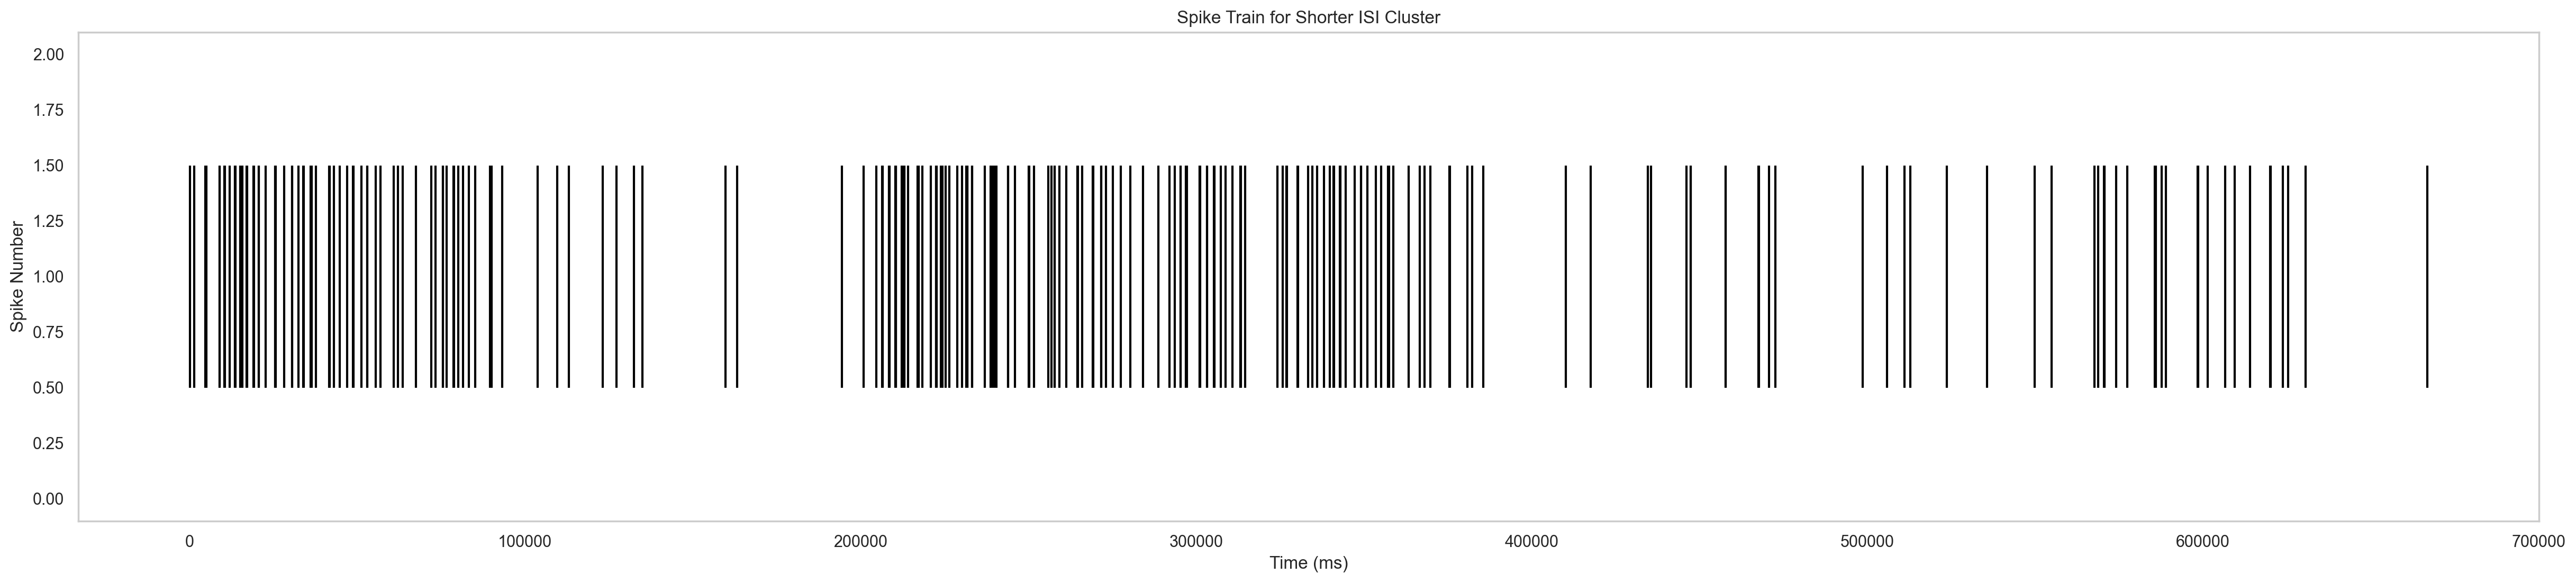

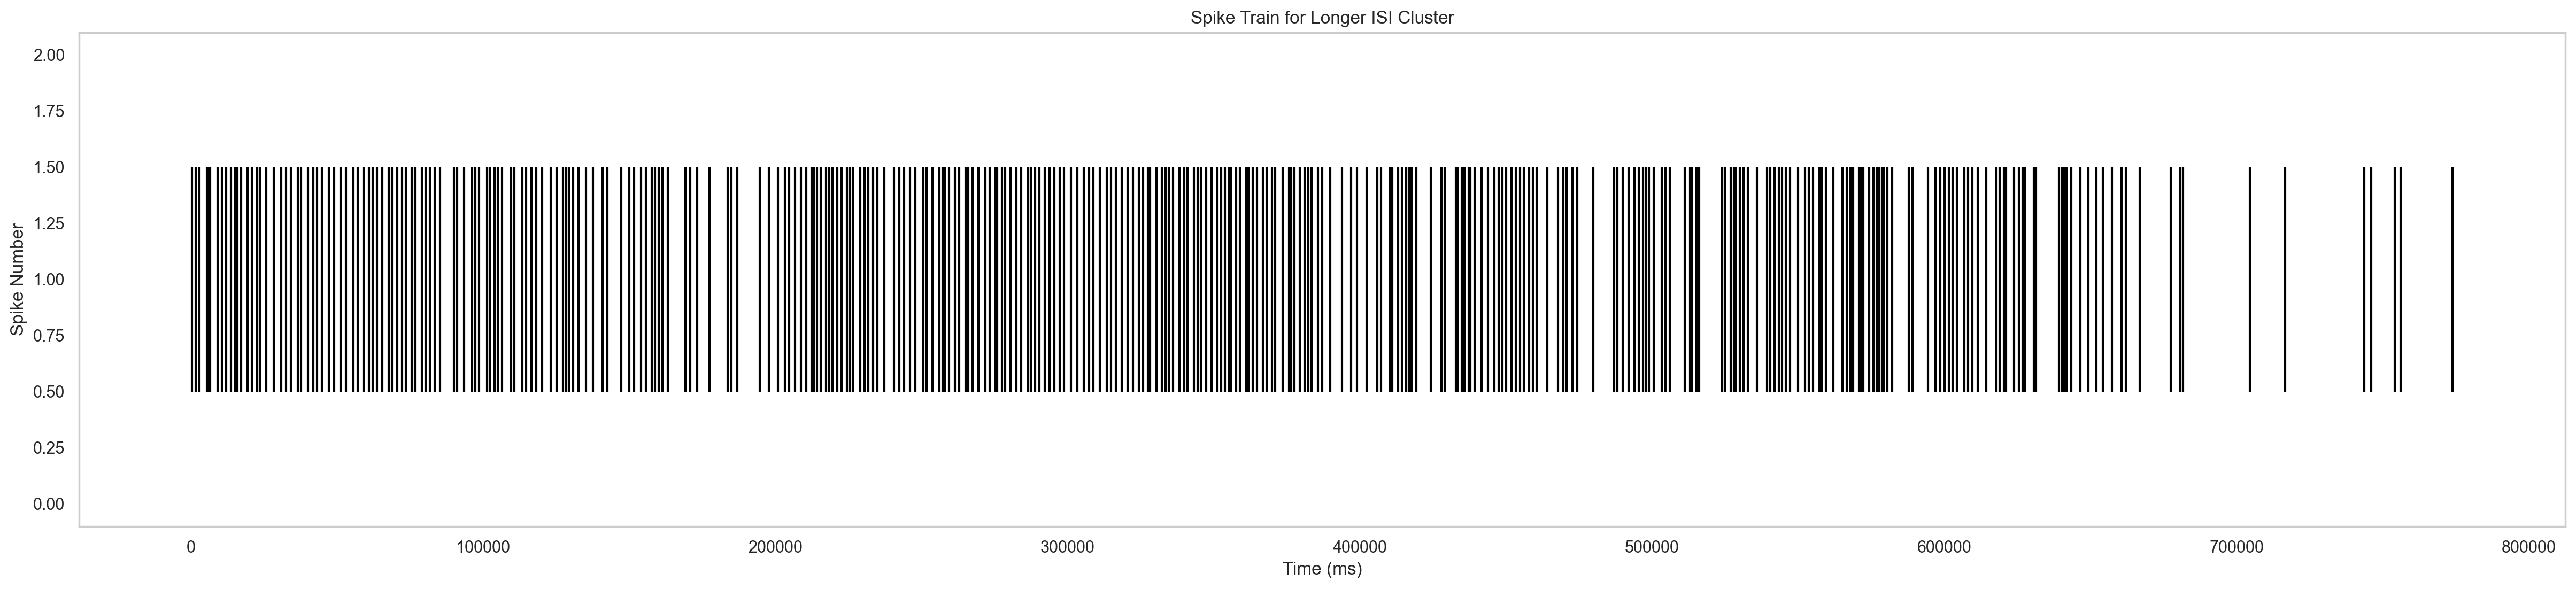

In [40]:


# Function to plot raster plot
def plot_raster(spike_indices, title):
    plt.figure(figsize=(30, 6))
    plt.eventplot(patch_times_c42[sp.spike_inds[spike_indices]], orientation='horizontal', colors='black')
    plt.xlabel('Time (ms)')
    plt.ylabel('Spike Number')
    plt.title(title)
    plt.show()

# Plot raster plots for both clusters
plot_raster(sorted_indices_shorter, 'Spike Train for Shorter ISI Cluster')
plot_raster(sorted_indices_longer, 'Spike Train for Longer ISI Cluster')


## Since the differences in the 3 models are mot stat sig - move forward just with the model without clustering based on ISI?

### Visualize model results 

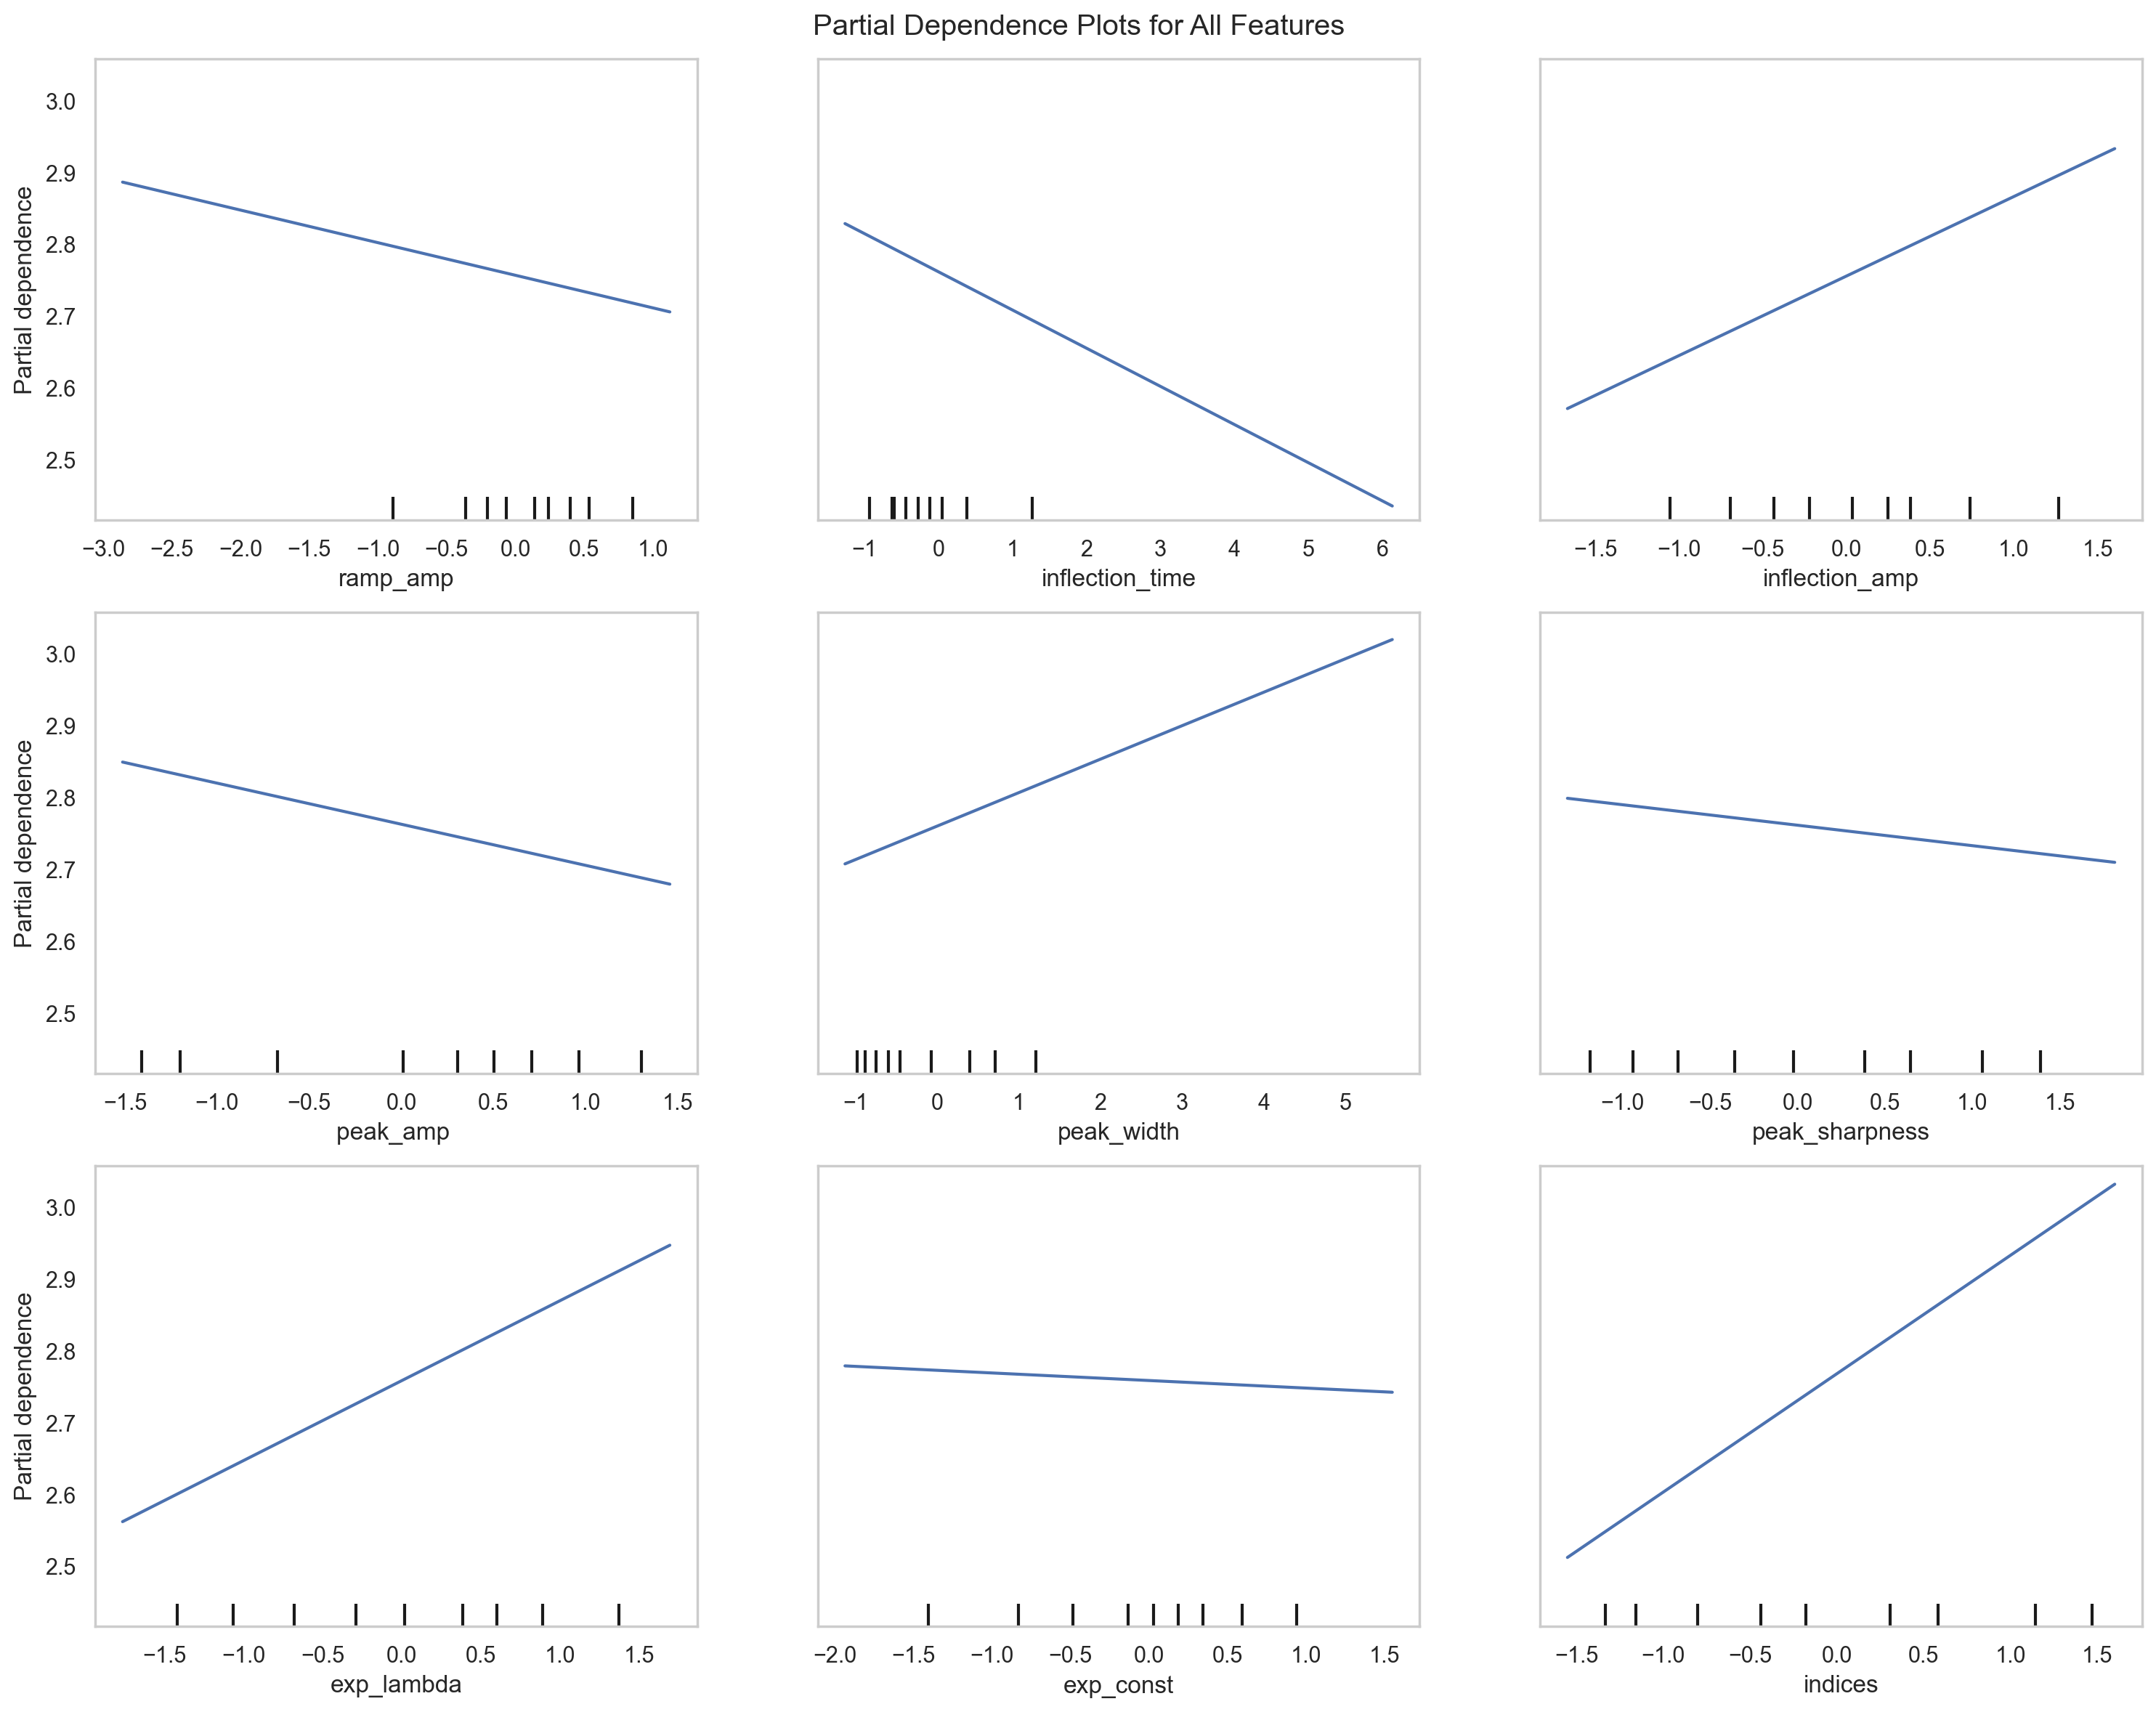

In [41]:
#FEATURE PARTIAL DEPENDANCE

from sklearn.inspection import PartialDependenceDisplay

# Create PDP for all features
fig, ax = plt.subplots(figsize=(15, 12))
PartialDependenceDisplay.from_estimator(model, X_test, range(len(actual_feature_names)), feature_names=actual_feature_names, ax=ax)
plt.suptitle('Partial Dependence Plots for All Features')
plt.tight_layout()
plt.show()


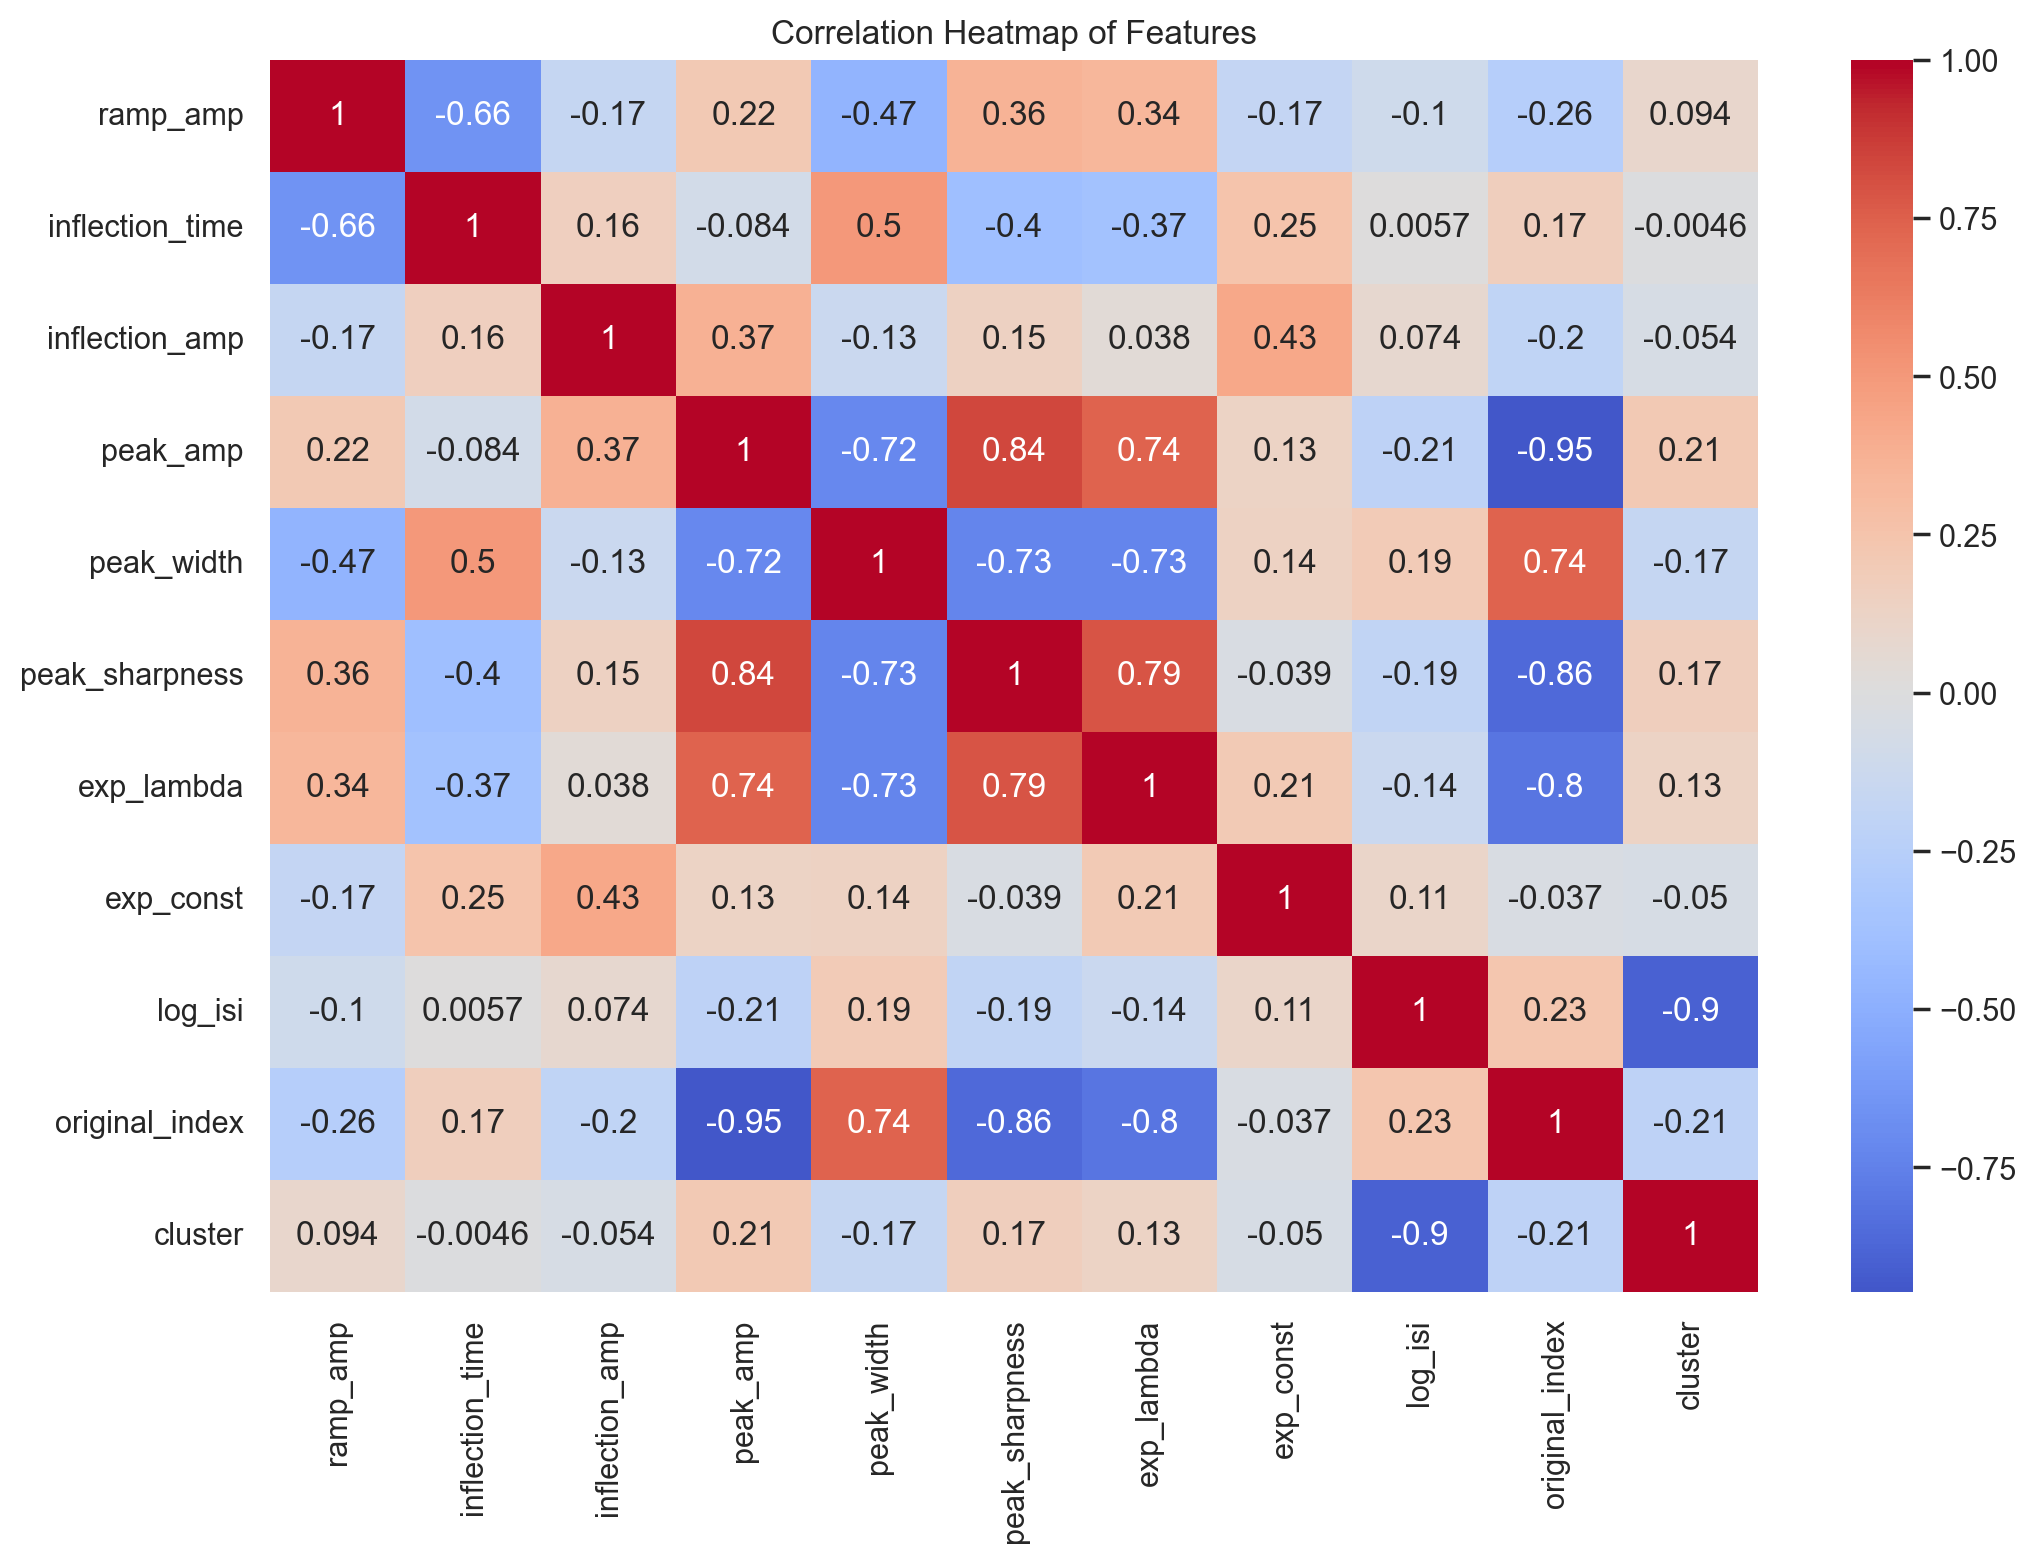

In [42]:
#see correlation matrix with orginal_index "feature"

correlation_matrix = df_features.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Features')
plt.show()